# CM3070 Final Year Project

## Deep Learning Breast Cancer Detection - Full Pipeline

### Merlin Melissa Jeyabal | University of London

This project investigates whether deep learning can support breast cancer screening using mammography images from the **CBIS-DDSM mass subset**.

The task is binary classification:

- **Benign**
- **Malignant**

The experimental pipeline progresses from a baseline convolutional neural network through controlled network-scaling, regularisation and resolution experiments, before moving to transfer learning, preprocessing enhancement, model selection, held-out test evaluation, robustness testing and interpretability analysis.

The main stages are:

1. Dataset preparation and patient-level train/validation/test splitting
2. Baseline CNN at 128×128 resolution
3. Network-scaling experiment using a deeper and wider custom CNN
4. Regularisation ablation using dropout-only, augmentation-only, and combined dropout + augmentation configurations
5. Regularised/scaled CNN comparison at 128×128 and 224×224 resolution
6. Transfer learning using VGG16 and ResNet50
7. CLAHE preprocessing applied to ResNet50
8. Principal model comparison using the validation set
9. Final model selection and freezing of the validation-derived decision threshold
10. Formal evaluation of the selected model on the held-out test set
11. Multi-seed robustness analysis using seeds 42, 7 and 123
12. McNemar significance testing between ResNet50 and ResNet50 + CLAHE
13. Grad-CAM qualitative visualisation and quantitative lesion-mask localisation analysis
14. Final results and discussion

The same patient-level train/validation/test split is maintained throughout the experiments. Model development, comparison and decision-threshold selection are performed using the validation set. Following model selection, the selected model is evaluated on the held-out test set using its frozen validation-derived threshold, keeping the held-out test set separate from the primary model-selection process.

Deterministic preprocessing is kept consistent where appropriate, while ImageNet-specific preprocessing is applied to pretrained networks. Data augmentation is applied only to the relevant regularisation experiments, and CLAHE is used only in the dedicated enhanced ResNet50 experiment.

The default random seed for the main experiments is **42**, with additional seeds **7** and **123** used for the multi-seed robustness analysis.

## Section 1: Setup

This section imports the libraries required for data processing, visualisation, model development and evaluation. Random seeds are also initialised to improve reproducibility across the main experiments.

In [1]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet50_preprocess,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay,
)
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

from google.colab import drive

drive.mount("/content/drive")

# Constants
SEED = 42
IMG_SIZE_128 = 128
IMG_SIZE_224 = 224
BATCH_SIZE = 32
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE
BASE = "/content/drive/MyDrive/cbis_ddsm"
JPEG = os.path.join(BASE, "jpeg")
CSV_PATH = os.path.join(BASE, "csv")
MODELS_DIR = os.path.join(BASE, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Reproducibility
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF :", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Seed:", SEED)

Mounted at /content/drive
TF : 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed: 42


In [2]:
MODELS_DIR = f"{BASE}/models_patientsplit_dedup"

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Saving corrected models to: {MODELS_DIR}")

Saving corrected models to: /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup


## Section 2: Load Dataset

The CBIS-DDSM mass-case training and test metadata are loaded and prepared for the classification pipeline. Pathology labels are converted into binary targets, where **1 = malignant** and **0 = benign**.

In [3]:
train_csv = pd.read_csv(os.path.join(CSV_PATH, "mass_case_description_train_set.csv"))
test_csv = pd.read_csv(os.path.join(CSV_PATH, "mass_case_description_test_set.csv"))

label_map = {"MALIGNANT": 1, "BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0}
train_csv["label"] = train_csv["pathology"].map(label_map)
test_csv["label"] = test_csv["pathology"].map(label_map)

train_csv.dropna(subset=["label"], inplace=True)
test_csv.dropna(subset=["label"], inplace=True)

print(
    f"Train: {len(train_csv)} | Malignant: {int(train_csv['label'].sum())} | Benign: {int((train_csv['label']==0).sum())}"
)
print(
    f"Test : {len(test_csv)} | Malignant: {int(test_csv['label'].sum())} | Benign: {int((test_csv['label']==0).sum())}"
)

Train: 1318 | Malignant: 637 | Benign: 681
Test : 378 | Malignant: 147 | Benign: 231


## Section 3: Map Image Paths

Image paths are mapped from the CBIS-DDSM metadata to the corresponding mammogram files using the available identifiers. This creates the file references required for subsequent preprocessing and dataset construction.

In [4]:
# Map mammogram paths and remove duplicates

jpeg_lookup = {
    folder: os.path.join(JPEG, folder, files[0])
    for folder in os.listdir(JPEG)
    if os.path.isdir(os.path.join(JPEG, folder))
    and (
        files := [
            f for f in os.listdir(os.path.join(JPEG, folder)) if f.endswith(".jpg")
        ]
    )
}

print(f"Total JPEG files indexed: {len(jpeg_lookup)}")


def get_image_path(csv_path):
    return next(
        (jpeg_lookup[p] for p in str(csv_path).split("/") if p in jpeg_lookup), None
    )


for df in [train_csv, test_csv]:
    df["full_path"] = df["image file path"].apply(get_image_path)
    df.dropna(subset=["full_path"], inplace=True)

# Preserve lesion-level metadata for later lesion-mask analysis
train_lesion_csv = train_csv.copy()
test_lesion_csv = test_csv.copy()

print("\nBEFORE DEDUPLICATION")
for name, df in [("Train", train_csv), ("Test", test_csv)]:
    conflicts = df.groupby("full_path")["label"].nunique()
    print(f"{name} rows: {len(df)} | Unique mammograms: {df['full_path'].nunique()}")
    print(
        f"{name} mammograms with conflicting lesion labels: "
        f"{int((conflicts > 1).sum())}"
    )

# Each physical mammogram must belong to one patient
for df in [train_csv, test_csv]:
    assert df.groupby("full_path")["patient_id"].nunique().max() == 1


def collapse_to_mammograms(df):
    labels = df.groupby("full_path")["label"].max()
    out = df.sort_values("label", ascending=False).drop_duplicates("full_path").copy()
    out["label"] = out["full_path"].map(labels).astype(int)
    return out.reset_index(drop=True)


train_csv = collapse_to_mammograms(train_csv)
test_csv = collapse_to_mammograms(test_csv)

print("\nAFTER DEDUPLICATION")
for name, df in [("Train", train_csv), ("Test", test_csv)]:
    print(f"{name} rows: {len(df)} | Unique mammograms: {df['full_path'].nunique()}")
    print(
        f"{name} malignant: {int(df['label'].sum())} | "
        f"Benign: {int((df['label'] == 0).sum())}"
    )
    assert len(df) == df["full_path"].nunique()

print("\n✓ Duplicate mammogram rows removed")
print("✓ Conflicting lesion labels collapsed to one image-level label")
print("✓ Malignant takes precedence if any lesion is malignant")

Total JPEG files indexed: 6774

BEFORE DEDUPLICATION
Train rows: 1318 | Unique mammograms: 1231
Train mammograms with conflicting lesion labels: 6
Test rows: 378 | Unique mammograms: 361
Test mammograms with conflicting lesion labels: 2

AFTER DEDUPLICATION
Train rows: 1231 | Unique mammograms: 1231
Train malignant: 602 | Benign: 629
Test rows: 361 | Unique mammograms: 361
Test malignant: 145 | Benign: 216

✓ Duplicate mammogram rows removed
✓ Conflicting lesion labels collapsed to one image-level label
✓ Malignant takes precedence if any lesion is malignant


## Section 4: Train / Validation / Test Split

A patient-grouped train/validation split is created using `GroupShuffleSplit` to prevent images from the same patient appearing in both partitions. The original CBIS-DDSM test partition is retained as the held-out test set.

Validation is used for model development, comparison and threshold selection, while the held-out test set is reserved for final evaluation after model selection.

In [5]:
# Patient-grouped train/val/test split

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

# Find split with validation prevalence closest to development set
overall_rate = train_csv["label"].mean()
best_seed, best_diff = None, np.inf

for seed in range(50):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    _, val_idx = next(gss.split(train_csv, groups=train_csv["patient_id"]))
    diff = abs(train_csv.iloc[val_idx]["label"].mean() - overall_rate)

    if diff < best_diff:
        best_seed, best_diff = seed, diff

print(f"Overall development-set malignant rate: {overall_rate*100:.1f}%")
print(f"Best seed found: {best_seed}")

# Final patient-grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=best_seed)
train_idx, val_idx = next(gss.split(train_csv, groups=train_csv["patient_id"]))

train_df = train_csv.iloc[train_idx].reset_index(drop=True)
val_df = train_csv.iloc[val_idx].reset_index(drop=True)

X_train = train_df["full_path"].values
y_train = train_df["label"].values.astype(np.float32)

X_val = val_df["full_path"].values
y_val = val_df["label"].values.astype(np.float32)

X_test = test_csv["full_path"].values
y_test = test_csv["label"].values.astype(np.float32)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(
    f"Malignant prevalence - Train: {y_train.mean()*100:.1f}% | "
    f"Val: {y_val.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%"
)

# Leakage checks
splits = [
    ("train", train_df, X_train),
    ("val", val_df, X_val),
    ("test", test_csv, X_test),
]

patient_sets = [set(df["patient_id"]) for _, df, _ in splits]
path_sets = [set(paths) for _, _, paths in splits]

assert not (patient_sets[0] & patient_sets[1])
assert not (patient_sets[0] & patient_sets[2])
assert not (patient_sets[1] & patient_sets[2])

assert not (path_sets[0] & path_sets[1])
assert not (path_sets[0] & path_sets[2])
assert not (path_sets[1] & path_sets[2])

for _, _, paths in splits:
    assert len(paths) == len(set(paths))

print("\n✓ No patient overlap")
print("✓ No mammogram overlap")
print("✓ No duplicate mammograms within any split")

class_weights = dict(
    enumerate(compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train))
)

print(f"\nClass weights: {class_weights}")

Overall development-set malignant rate: 48.9%
Best seed found: 8

Train: 979 | Val: 252 | Test: 361
Malignant prevalence — Train: 48.9% | Val: 48.8% | Test: 40.2%

✓ No patient overlap
✓ No mammogram overlap
✓ No duplicate mammograms within any split

Class weights: {0: np.float64(0.979), 1: np.float64(1.0219206680584552)}


## Section 5: Data Pipeline - 128×128 and 224×224

Mammograms are cropped to remove surrounding black regions and resized with padding to either **128×128** or **224×224** while preserving aspect ratio. The processed arrays are cached for reuse across experiments.

Data augmentation is applied only to the relevant training experiments, while validation and test data remain unaugmented.

In [6]:
# Image pipeline with deduplicated caches


def load_image(path, label):
    image = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    return image, label


def crop_to_content(image, threshold=10):
    gray = tf.image.rgb_to_grayscale(tf.cast(image, tf.float32))[:, :, 0]
    mask = gray > threshold

    row_idx = tf.where(tf.reduce_any(mask, axis=1))
    col_idx = tf.where(tf.reduce_any(mask, axis=0))

    def crop():
        top, bottom = tf.reduce_min(row_idx), tf.reduce_max(row_idx) + 1
        left, right = tf.reduce_min(col_idx), tf.reduce_max(col_idx) + 1
        return image[top:bottom, left:right, :]

    return tf.cond(
        tf.logical_and(tf.size(row_idx) > 0, tf.size(col_idx) > 0), crop, lambda: image
    )


def preprocess(image, label, img_size):
    image = crop_to_content(image)
    image = tf.image.resize_with_pad(image, img_size, img_size)
    return tf.cast(image, tf.float32) / 255.0, label


def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return tf.clip_by_value(image, 0.0, 1.0), label


def build_pipeline(paths, labels, img_size):
    return (
        tf.data.Dataset.from_tensor_slices((paths, labels))
        .map(load_image, num_parallel_calls=AUTOTUNE)
        .map(lambda x, y: preprocess(x, y, img_size), num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


def cache_dataset(ds, name):
    batches = list(ds.as_numpy_iterator())
    images = np.concatenate([x for x, _ in batches])
    labels = np.concatenate([y for _, y in batches])

    np.save(f"{BASE}/{name}_images.npy", images)
    np.save(f"{BASE}/{name}_labels.npy", labels)
    print(f"Saved {name} - {len(labels)} samples")


def load_cached(name, shuffle=False, augmentation=False):
    images = np.load(f"{BASE}/{name}_images.npy")
    labels = np.load(f"{BASE}/{name}_labels.npy")

    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        ds = ds.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)

    if augmentation:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def get_dataset(name, paths, labels, img_size, shuffle=False, augmentation=False):

    cache = f"{name}_{img_size}_dedup_v1"

    if not os.path.exists(f"{BASE}/{cache}_images.npy"):
        print(f"[{name}@{img_size}] building NEW deduplicated cache...")
        cache_dataset(build_pipeline(paths, labels, img_size), cache)
    else:
        print(f"[{name}@{img_size}] reusing corrected cache")

    return load_cached(cache, shuffle, augmentation)


# 128×128
train_ds_128_plain = get_dataset("train", X_train, y_train, IMG_SIZE_128, shuffle=True)
train_ds_128_aug = get_dataset(
    "train", X_train, y_train, IMG_SIZE_128, shuffle=True, augmentation=True
)
val_ds_128 = get_dataset("val", X_val, y_val, IMG_SIZE_128)
test_ds_128 = get_dataset("test", X_test, y_test, IMG_SIZE_128)

# 224×224
train_ds_224_plain = get_dataset("train", X_train, y_train, IMG_SIZE_224, shuffle=True)
train_ds_224_aug = get_dataset(
    "train", X_train, y_train, IMG_SIZE_224, shuffle=True, augmentation=True
)
val_ds_224 = get_dataset("val", X_val, y_val, IMG_SIZE_224)
test_ds_224 = get_dataset("test", X_test, y_test, IMG_SIZE_224)

# Original downstream name
train_ds_224 = train_ds_224_aug

print("\n✓ Corrected standard pipelines ready")

[train@128] reusing corrected cache
[train@128] reusing corrected cache
[val@128] reusing corrected cache
[test@128] reusing corrected cache
[train@224] reusing corrected cache
[train@224] reusing corrected cache
[val@224] reusing corrected cache
[test@224] reusing corrected cache

✓ Corrected standard pipelines ready


## Section 6: Evaluation and Plotting Utilities

Reusable functions are defined to ensure consistent evaluation across all experiments. Performance is measured using accuracy, sensitivity, specificity, precision, ROC-AUC and confusion matrices.

Decision thresholds are selected from validation predictions using **Youden's J statistic**, allowing the chosen threshold to be frozen when required for later evaluation.

In [6]:
# Evaluation utilities


def evaluate_model(
    model, dataset, name="Model", threshold=0.5, split_name="Validation", verbose=True
):

    y_prob = model.predict(dataset, verbose=0).ravel()
    y_true = np.concatenate([y.numpy() for _, y in dataset]).astype(int)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        "model": name,
        "threshold": round(float(threshold), 4),
        "accuracy": round((tp + tn) / len(y_true), 4),
        "sensitivity": round(tp / (tp + fn), 4) if tp + fn else 0.0,
        "specificity": round(tn / (tn + fp), 4) if tn + fp else 0.0,
        "precision": round(tp / (tp + fp), 4) if tp + fp else 0.0,
        "auc": round(roc_auc_score(y_true, y_prob), 4),
        "cm": cm,
        "y_prob": y_prob,
        "y_true": y_true,
    }

    if verbose:
        print(
            f"\n{'='*60}\n{name} - {split_name} Results "
            f"(threshold={threshold:.3f})\n{'='*60}"
        )
        print(
            classification_report(y_true, y_pred, target_names=["Benign", "Malignant"])
        )
        print(f"Accuracy    : {results['accuracy']}")
        print(
            f"Sensitivity : {results['sensitivity']}  "
            f"(missed {fn} of {fn+tp} malignant cases)"
        )
        print(f"Specificity : {results['specificity']}")
        print(f"Precision   : {results['precision']}")
        print(f"AUC         : {results['auc']}")

    return results


def find_best_threshold(model, val_ds, verbose=True):
    y_prob = model.predict(val_ds, verbose=0).ravel()
    y_true = np.concatenate([y.numpy() for _, y in val_ds]).astype(int)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    i = int(np.argmax(tpr - fpr))
    threshold = float(np.clip(thresholds[i], 0.0, 1.0))

    if verbose:
        print(
            f"Optimal threshold (Youden's J): {threshold:.3f}  "
            f"(val sensitivity={tpr[i]:.3f}, "
            f"val specificity={1-fpr[i]:.3f})"
        )

    return threshold


def plot_confusion_matrix(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5, 5))

    ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d"
    )

    ax.set_title(title, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


def plot_training_curves(history, title, save_path=None):
    hist = history.history if hasattr(history, "history") else history
    metrics = [m for m in ["loss", "accuracy", "auc", "sensitivity"] if m in hist]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    axes = [axes] if len(metrics) == 1 else axes

    for ax, metric in zip(axes, metrics):
        ax.plot(hist[metric], label="Train")

        if f"val_{metric}" in hist:
            ax.plot(hist[f"val_{metric}"], label="Val")

        ax.set_title(metric.upper())
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.suptitle(title, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


print("Evaluation utilities ready.")

Evaluation utilities ready.


In [7]:
def plot_roc_curve(results, title=None, save_path=None):
    """Plot the ROC curve for a single model's results dict (as returned by
    evaluate_model, which now also stores y_prob/y_true). This is the
    threshold-independent counterpart to the confusion matrix - reused for
    every transfer-learning model from here on (VGG16, ResNet50, etc.).
    """
    fpr, tpr, _ = roc_curve(results["y_true"], results["y_prob"])
    plt.figure(figsize=(5.5, 5.5))
    plt.plot(
        fpr, tpr, linewidth=2, label=f"{results['model']} (AUC = {results['auc']:.3f})"
    )
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title or f"ROC Curve - {results['model']}", fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


print("ROC-curve utility ready.")

ROC-curve utility ready.


## Section 7: Grad-CAM Utilities

Reusable Grad-CAM functions are defined to visualise image regions contributing to model predictions. These utilities support qualitative interpretability analysis during model development.

A separate analysis later examines the final ResNet50 + CLAHE model in greater detail using both prediction cases and lesion-mask localisation.

In [8]:
def make_gradcam(img_array, model):
    last_conv = None

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer.name

    if last_conv is None:
        raise ValueError("No Conv2D layer found in model.")

    if isinstance(model, tf.keras.Sequential):
        # Rebuild a simple functional graph for Sequential models
        img_input = tf.keras.Input(shape=img_array.shape[1:])
        x = img_input
        conv_output = None

        for layer in model.layers:
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue
            x = layer(x)
            if layer.name == last_conv:
                conv_output = x

        grad_model = tf.keras.Model(inputs=img_input, outputs=[conv_output, x])
    else:
        # Functional transfer models already expose their graph
        grad_model = tf.keras.Model(
            inputs=model.input,
            outputs=[model.get_layer(last_conv).output, model.output],
        )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tf.cast(img_array, tf.float32), training=False)
        loss = tf.reduce_sum(preds[:, 0])

    grads = tape.gradient(loss, conv_out)

    if grads is None:
        raise ValueError("Could not calculate Grad-CAM gradients.")

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def prepare_gradcam_image(img_path, img_size, model_type="standard"):
    # Match the preprocessing used by the training pipeline
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = crop_to_content(image)
    image = tf.image.resize_with_pad(image, img_size, img_size)

    display_img = tf.cast(image, tf.float32) / 255.0

    if model_type == "vgg16":
        model_img = vgg16_preprocess(tf.cast(image, tf.float32))
    elif model_type == "resnet50":
        model_img = resnet50_preprocess(tf.cast(image, tf.float32))
    else:
        model_img = display_img

    return model_img.numpy(), display_img.numpy()


# Fixed set of 4 test cases, reused for every model
mal_samples = test_csv[test_csv["label"] == 1]["full_path"].iloc[:2].tolist()
ben_samples = test_csv[test_csv["label"] == 0]["full_path"].iloc[:2].tolist()
GRADCAM_SAMPLES = mal_samples + ben_samples
GRADCAM_LABELS = ["MALIGNANT", "MALIGNANT", "BENIGN", "BENIGN"]


def plot_gradcam_grid(
    model, model_name, img_size, threshold=0.5, model_type="standard", save_path=None
):
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))

    for i, (path, true) in enumerate(zip(GRADCAM_SAMPLES, GRADCAM_LABELS)):
        model_img, display_img = prepare_gradcam_image(
            path, img_size, model_type=model_type
        )

        arr = np.expand_dims(model_img, 0).astype(np.float32)
        prob = float(model.predict(arr, verbose=0)[0][0])

        pred = "MALIGNANT" if prob >= threshold else "BENIGN"
        mark = "CORRECT" if pred == true else "WRONG"
        color = "green" if mark == "CORRECT" else "red"

        heatmap = make_gradcam(arr, model)
        hm_r = (
            tf.image.resize(heatmap[..., np.newaxis], (img_size, img_size))
            .numpy()
            .squeeze()
        )
        colored = plt.get_cmap("jet")(hm_r)[:, :, :3]
        overlay = np.clip(colored * 0.4 + display_img * 0.6, 0, 1)

        axes[i][0].imshow(display_img, cmap="gray")
        axes[i][0].set_title(f"True: {true}", fontsize=9)
        axes[i][0].axis("off")

        axes[i][1].imshow(heatmap, cmap="jet")
        axes[i][1].set_title("Grad-CAM Heatmap", fontsize=9)
        axes[i][1].axis("off")

        axes[i][2].imshow(overlay)
        axes[i][2].set_title(
            f"Pred: {pred} ({prob:.2f}) [{mark}]", fontsize=9, color=color
        )
        axes[i][2].axis("off")

    plt.suptitle(
        f"Grad-CAM Visualisation - {model_name}\n"
        f"Left: Input | Middle: Heatmap | Right: Overlay",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


print("Grad-CAM utilities ready.")

Grad-CAM utilities ready.


## Section 8: Training and Checkpointing

Training utilities use early stopping and model checkpointing to retain the best-performing model based on validation performance. Saved `.keras` checkpoints are then reused for subsequent evaluation.

Transfer-learning models additionally use staged training, beginning with a frozen pretrained base before selective fine-tuning.

In [9]:
def train_model(
    model,
    train_ds,
    val_ds,
    checkpoint_path,
    epochs=EPOCHS,
    patience=7,
    class_weight=None,
):
    callbacks = [
        EarlyStopping(
            monitor="val_auc",
            patience=patience,
            restore_best_weights=True,
            mode="max",
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_auc",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
    ]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weight,
    )
    best_epoch = int(np.argmax(history.history["val_auc"]) + 1)
    print(
        f"\nBest epoch: {best_epoch} | Best val_auc: {max(history.history['val_auc']):.4f}"
    )
    return history, best_epoch

## Section 9: Baseline CNN - Architecture

The baseline model is a **128×128 CNN** with three convolutional blocks followed by global average pooling, a dense layer and a sigmoid output. No dropout or data augmentation is applied, providing an unregularised reference model for the subsequent experiments.

In [11]:
def build_baseline_cnn(img_size=IMG_SIZE_128, name="Baseline_CNN"):
    model = tf.keras.Sequential(
        [
            layers.Conv2D(
                32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)
            ),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ],
        name=name,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )
    return model


baseline_model = build_baseline_cnn(IMG_SIZE_128)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## Section 10: Train Baseline CNN

The baseline CNN is trained on the 128×128 training set using class weighting. Early stopping and model checkpointing monitor validation AUC so that the best-performing model state is retained.

In [35]:
# Baseline uses the plain 128px training set
baseline_history, baseline_best_epoch = train_model(
    baseline_model,
    train_ds_128_plain,
    val_ds_128,
    checkpoint_path=f"{MODELS_DIR}/baseline_cnn_best.keras",
    class_weight=class_weights,
)

Epoch 1/30
28/31 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6148 - auc: 0.6721 - loss: 0.6560 - precision: 0.5875 - sensitivity: 0.7814
Epoch 1: val_auc improved from None to 0.68813, saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/baseline_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/baseline_cnn_best.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6057 - auc: 0.6437 - loss: 0.6609 - precision: 0.5917 - sensitivity: 0.6263 - val_accuracy: 0.6548 - val_auc: 0.6881 - val_loss: 0.6441 - val_precision: 0.6500 - val_sensitivity: 0.6341
Epoch 2/30
28/31 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6269 - auc: 0.6306 - loss: 0.6700 - precision: 0.6241 - sensitivity: 0.6875
Epoch 2: val_auc did not improve from 0.68813
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6343 - auc: 0.6531 - loss: 0.6581 - precision: 0.6179 - sensitivity: 0.6618 - val_accuracy: 0.6548 - val_auc: 0.6

## Section 11: Baseline CNN - Training and Validation Performance

Training curves are examined to assess learning behaviour and potential overfitting. The baseline model is then evaluated on the validation set using a threshold selected with Youden's J statistic, establishing a reference for subsequent experiments.

Loaded saved Baseline CNN model.
Optimal threshold (Youden's J): 0.531  (val sensitivity=0.634, val specificity=0.698)

Baseline CNN (128px) — Validation Results (threshold=0.531)
              precision    recall  f1-score   support

      Benign       0.67      0.70      0.68       129
   Malignant       0.67      0.63      0.65       123

    accuracy                           0.67       252
   macro avg       0.67      0.67      0.67       252
weighted avg       0.67      0.67      0.67       252

Accuracy    : 0.6667
Sensitivity : 0.6341  (missed 45 of 123 malignant cases)
Specificity : 0.6977
Precision   : 0.6667
AUC         : 0.6938


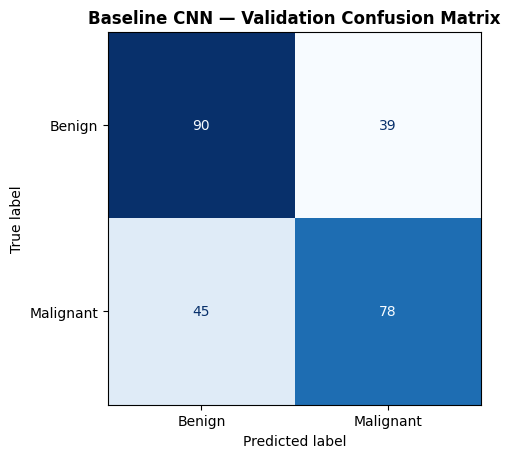

In [13]:
# Baseline CNN validation results (no retraining needed)

import tensorflow as tf

# Load saved best model
baseline_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/baseline_cnn_best.keras", compile=False
)

print("Loaded saved Baseline CNN model.")


# Validation threshold

baseline_threshold = find_best_threshold(baseline_model, val_ds_128)


# Validation evaluation

baseline_results = evaluate_model(
    baseline_model,
    val_ds_128,
    name="Baseline CNN (128px)",
    threshold=baseline_threshold,
    split_name="Validation",
)


# Validation confusion matrix

plot_confusion_matrix(
    baseline_results["cm"],
    "Baseline CNN - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_baseline_validation.png",
)

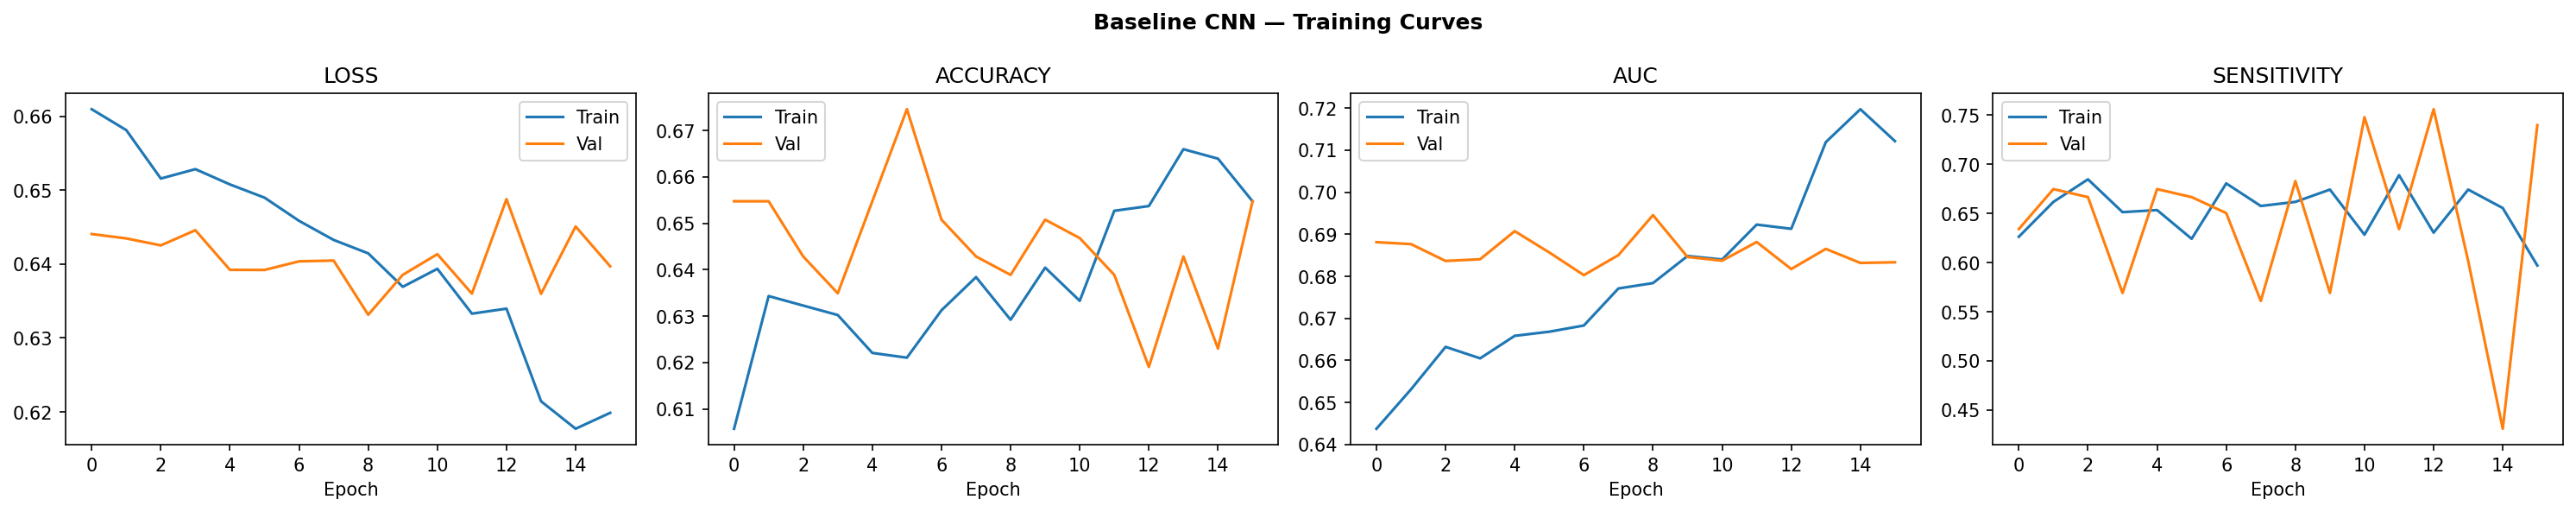

In [12]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_baseline.png"))

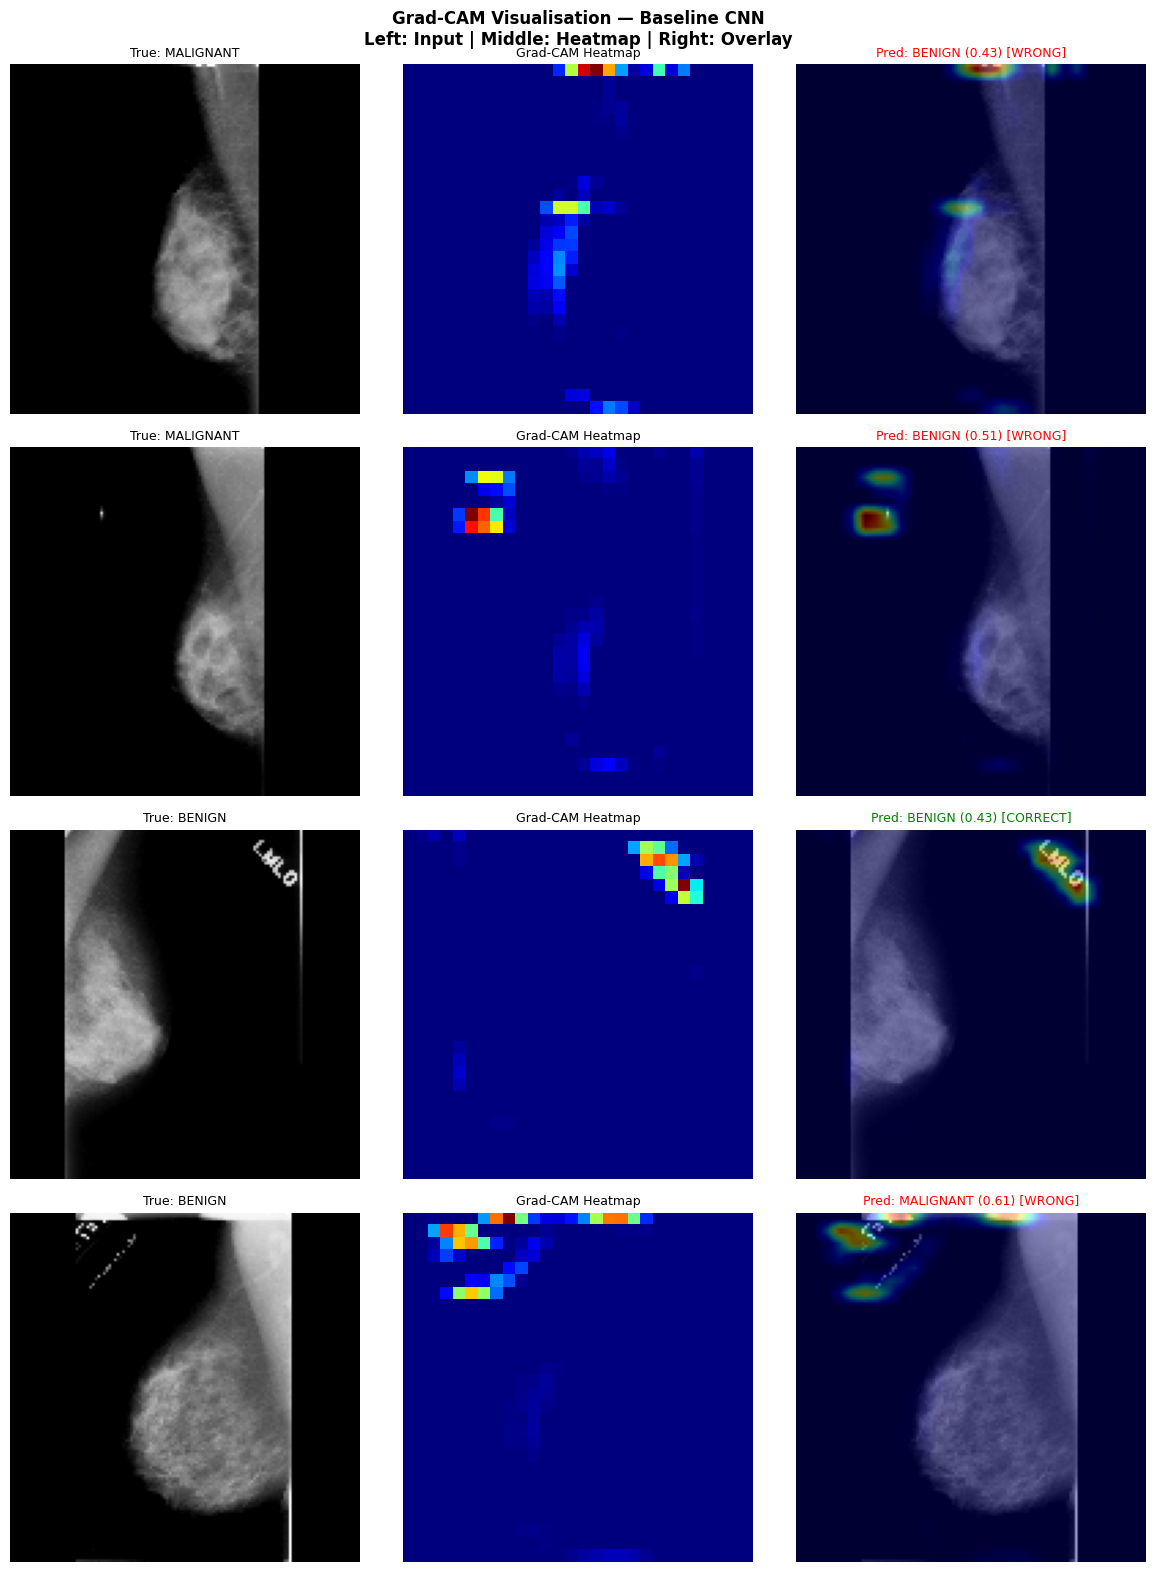

In [14]:
plot_gradcam_grid(
    baseline_model,
    "Baseline CNN",
    IMG_SIZE_128,
    threshold=baseline_threshold,
    save_path=f"{BASE}/gradcam_baseline.png",
)

## Section 12: Network Scaling Experiment

The baseline CNN is made deeper and wider while retaining the **128×128 input resolution**. This controlled experiment examines whether increasing model capacity improves validation performance and generalisation.

In [22]:
# Network scaling experiment: train + validate


def make_cnn(scaled=False):
    filters = [32, 64, 128, 256] if scaled else [32, 64, 128]

    model = tf.keras.Sequential([layers.Input((128, 128, 3))])

    for f in filters:
        model.add(layers.Conv2D(f, 3, activation="relu"))
        model.add(layers.MaxPooling2D())

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256 if scaled else 128, activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    return model


# Build models

baseline_scaling_model = make_cnn(scaled=False)
scaled_model = make_cnn(scaled=True)


# Train both models (data: train_ds_128_plain, monitor: val_ds_128)

baseline_scaling_history, _ = train_model(
    baseline_scaling_model,
    train_ds_128_plain,
    val_ds_128,
    f"{MODELS_DIR}/baseline_scaling_best.keras",
    class_weight=class_weights,
)

scaled_history, _ = train_model(
    scaled_model,
    train_ds_128_plain,
    val_ds_128,
    f"{MODELS_DIR}/scaled_cnn_best.keras",
    class_weight=class_weights,
)


# Select thresholds using validation set only

baseline_threshold = find_best_threshold(baseline_scaling_model, val_ds_128)

scaled_threshold = find_best_threshold(scaled_model, val_ds_128)


# Evaluate on validation set only

baseline_scaling_results = evaluate_model(
    baseline_scaling_model,
    val_ds_128,
    name="Baseline CNN (128px)",
    threshold=baseline_threshold,
    split_name="Validation",
)

scaled_results = evaluate_model(
    scaled_model,
    val_ds_128,
    name="Scaled CNN (128px)",
    threshold=scaled_threshold,
    split_name="Validation",
)


# Validation-only network scaling comparison

print("\n" + "=" * 60)
print("NETWORK SCALING - VALIDATION COMPARISON")
print("=" * 60)

for name, r in [
    ("Baseline CNN (128px)", baseline_scaling_results),
    ("Scaled CNN (128px)", scaled_results),
]:
    print(f"\n{name}")
    print(f"Threshold   : {r['threshold']:.4f}")
    print(f"Accuracy    : {r['accuracy']:.4f}")
    print(f"Sensitivity : {r['sensitivity']:.4f}")
    print(f"Specificity : {r['specificity']:.4f}")
    print(f"Precision   : {r['precision']:.4f}")
    print(f"AUC         : {r['auc']:.4f}")


auc_change = scaled_results["auc"] - baseline_scaling_results["auc"]

print(
    f"\nValidation AUC change: "
    f"{baseline_scaling_results['auc']:.4f} → "
    f"{scaled_results['auc']:.4f} "
    f"({auc_change:+.4f})"
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4867 - auc: 0.4687 - loss: 0.6955 - precision: 0.4878 - sensitivity: 0.8367
Epoch 1: val_auc improved from None to 0.50000, saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/baseline_scaling_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/baseline_scaling_best.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.4709 - auc: 0.4742 - loss: 0.6946 - precision: 0.4686 - sensitivity: 0.6075 - val_accuracy: 0.5119 - val_auc: 0.5000 - val_loss: 0.6929 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4883 - auc: 0.4735 - loss: 0.6932 - precision: 0.3586 - sensitivity: 0.2342
Epoch 2: val_auc improved from 0.50000 to 0.55701, saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/baseline_scaling_best.keras

Epoch 2: finished saving model to /conten

## Section 13: Regularisation Ablation Experiment

Regularisation is investigated using the 128×128 baseline architecture. Four configurations are compared: **baseline, dropout only, augmentation only, and combined dropout + augmentation**.

The same data split and evaluation procedure are retained to isolate the effects of the regularisation strategies.

In [15]:
# Regularisation ablation: dropout only vs augmentation only


def build_ablation_cnn(dropout=False, name="CNN"):
    model = tf.keras.Sequential(
        [
            layers.Input((128, 128, 3)),
            layers.Conv2D(32, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(128, 3, activation="relu"),
            layers.MaxPooling2D(),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
        ],
        name=name,
    )

    if dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    return model

### Section 13.1: Dropout-Only CNN


In [ ]:
# Experiment 1: dropout only

dropout_model = build_ablation_cnn(dropout=True, name="CNN_Dropout_Only")

dropout_history, dropout_best_epoch = train_model(
    dropout_model,
    train_ds_128_plain,  # NO augmentation
    val_ds_128,
    checkpoint_path=f"{MODELS_DIR}/cnn_dropout_only_best.keras",
    class_weight=class_weights,
)

In [17]:
# Dropout-only CNN validation results

# Load saved model
dropout_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/cnn_dropout_only_best.keras", compile=False
)

# Find threshold using VALIDATION only
dropout_threshold = find_best_threshold(dropout_model, val_ds_128)

# Evaluate on VALIDATION only
dropout_results = evaluate_model(
    dropout_model,
    val_ds_128,
    name="CNN - Dropout Only",
    threshold=dropout_threshold,
    split_name="Validation",
)

print("Dropout-only validation evaluation complete.")

Optimal threshold (Youden's J): 0.525  (val sensitivity=0.528, val specificity=0.775)

CNN — Dropout Only — Validation Results (threshold=0.525)
              precision    recall  f1-score   support

      Benign       0.63      0.78      0.70       129
   Malignant       0.69      0.53      0.60       123

    accuracy                           0.65       252
   macro avg       0.66      0.65      0.65       252
weighted avg       0.66      0.65      0.65       252

Accuracy    : 0.6548
Sensitivity : 0.5285  (missed 58 of 123 malignant cases)
Specificity : 0.7752
Precision   : 0.6915
AUC         : 0.6818
Dropout-only validation evaluation complete.


### Section 13.2: Augmentation-Only CNN

In [ ]:
# Experiment 2: augmentation only

augmentation_model = build_ablation_cnn(dropout=False, name="CNN_Augmentation_Only")

augmentation_history, augmentation_best_epoch = train_model(
    augmentation_model,
    train_ds_128_aug,  # augmentation ON
    val_ds_128,
    checkpoint_path=f"{MODELS_DIR}/cnn_augmentation_only_best.keras",
    class_weight=class_weights,
)

In [18]:
# Augmentation-only CNN validation results

augmentation_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/cnn_augmentation_only_best.keras", compile=False
)

augmentation_threshold = find_best_threshold(augmentation_model, val_ds_128)

augmentation_results = evaluate_model(
    augmentation_model,
    val_ds_128,
    name="CNN - Augmentation Only",
    threshold=augmentation_threshold,
    split_name="Validation",
)

print("Augmentation-only validation evaluation complete.")

Optimal threshold (Youden's J): 0.501  (val sensitivity=0.667, val specificity=0.636)

CNN — Augmentation Only — Validation Results (threshold=0.501)
              precision    recall  f1-score   support

      Benign       0.67      0.64      0.65       129
   Malignant       0.64      0.67      0.65       123

    accuracy                           0.65       252
   macro avg       0.65      0.65      0.65       252
weighted avg       0.65      0.65      0.65       252

Accuracy    : 0.6508
Sensitivity : 0.6667  (missed 41 of 123 malignant cases)
Specificity : 0.6357
Precision   : 0.6357
AUC         : 0.6812
Augmentation-only validation evaluation complete.


### Section 13.3: Combined Dropout + Augmentation CNN

In [12]:
def build_regularised_cnn(img_size, name="Regularised_CNN"):
    model = tf.keras.Sequential(
        [
            layers.Conv2D(
                32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)
            ),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.5),  # regularisation added here vs. baseline
            layers.Dense(1, activation="sigmoid"),
        ],
        name=name,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )
    return model


build_regularised_cnn(IMG_SIZE_128).summary()

Model: "Regularised_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
reg128_model = build_regularised_cnn(IMG_SIZE_128, name="Regularised_CNN_128")

# Regularised CNN uses dynamic augmentation
reg128_history, reg128_best_epoch = train_model(
    reg128_model,
    train_ds_128_aug,
    val_ds_128,
    checkpoint_path=f"{MODELS_DIR}/regularised_cnn_128_best.keras",
    class_weight=class_weights,
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4967 - auc: 0.4542 - loss: 0.6958 - precision: 0.4480 - sensitivity: 0.2303
Epoch 1: val_auc improved from None to 0.49319, saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/regularised_cnn_128_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/regularised_cnn_128_best.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.4770 - auc: 0.4644 - loss: 0.6953 - precision: 0.4510 - sensitivity: 0.3173 - val_accuracy: 0.5119 - val_auc: 0.4932 - val_loss: 0.6929 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 2/30
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4904 - auc: 0.5091 - loss: 0.6931 - precision: 0.4886 - sensitivity: 0.4251
Epoch 2: val_auc improved from 0.49319 to 0.50000, saving model to /content/drive/MyDrive/cbis_ddsm/models_patientsplit_dedup/regularised_cnn_128_best.keras

Epoch 2: finished saving model 

Optimal threshold (Youden's J): 0.538  (val sensitivity=0.610, val specificity=0.760)

Regularised CNN (128px) — Validation Results (threshold=0.538)
              precision    recall  f1-score   support

      Benign       0.67      0.76      0.71       129
   Malignant       0.71      0.61      0.66       123

    accuracy                           0.69       252
   macro avg       0.69      0.68      0.68       252
weighted avg       0.69      0.69      0.68       252

Accuracy    : 0.6865
Sensitivity : 0.6098  (missed 48 of 123 malignant cases)
Specificity : 0.7597
Precision   : 0.7075
AUC         : 0.7032


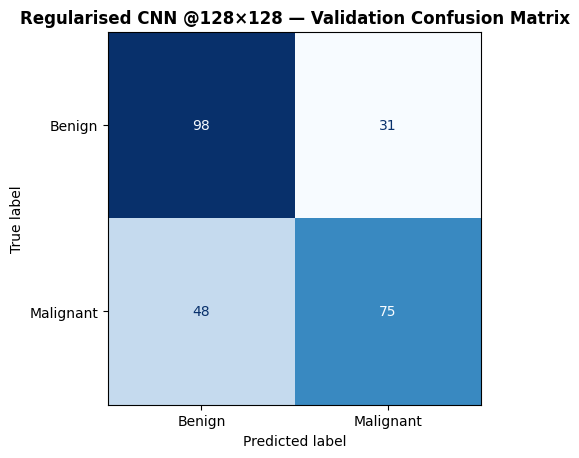

Regularised CNN validation evaluation complete.


In [20]:
# Regularised CNN (128px) validation results

reg128_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/regularised_cnn_128_best.keras", compile=False
)

reg128_threshold = find_best_threshold(reg128_model, val_ds_128)

reg128_results = evaluate_model(
    reg128_model,
    val_ds_128,
    name="Regularised CNN (128px)",
    threshold=reg128_threshold,
    split_name="Validation",
)

plot_confusion_matrix(
    reg128_results["cm"],
    "Regularised CNN @128×128 - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_reg128_validation.png",
)

print("Regularised CNN validation evaluation complete.")

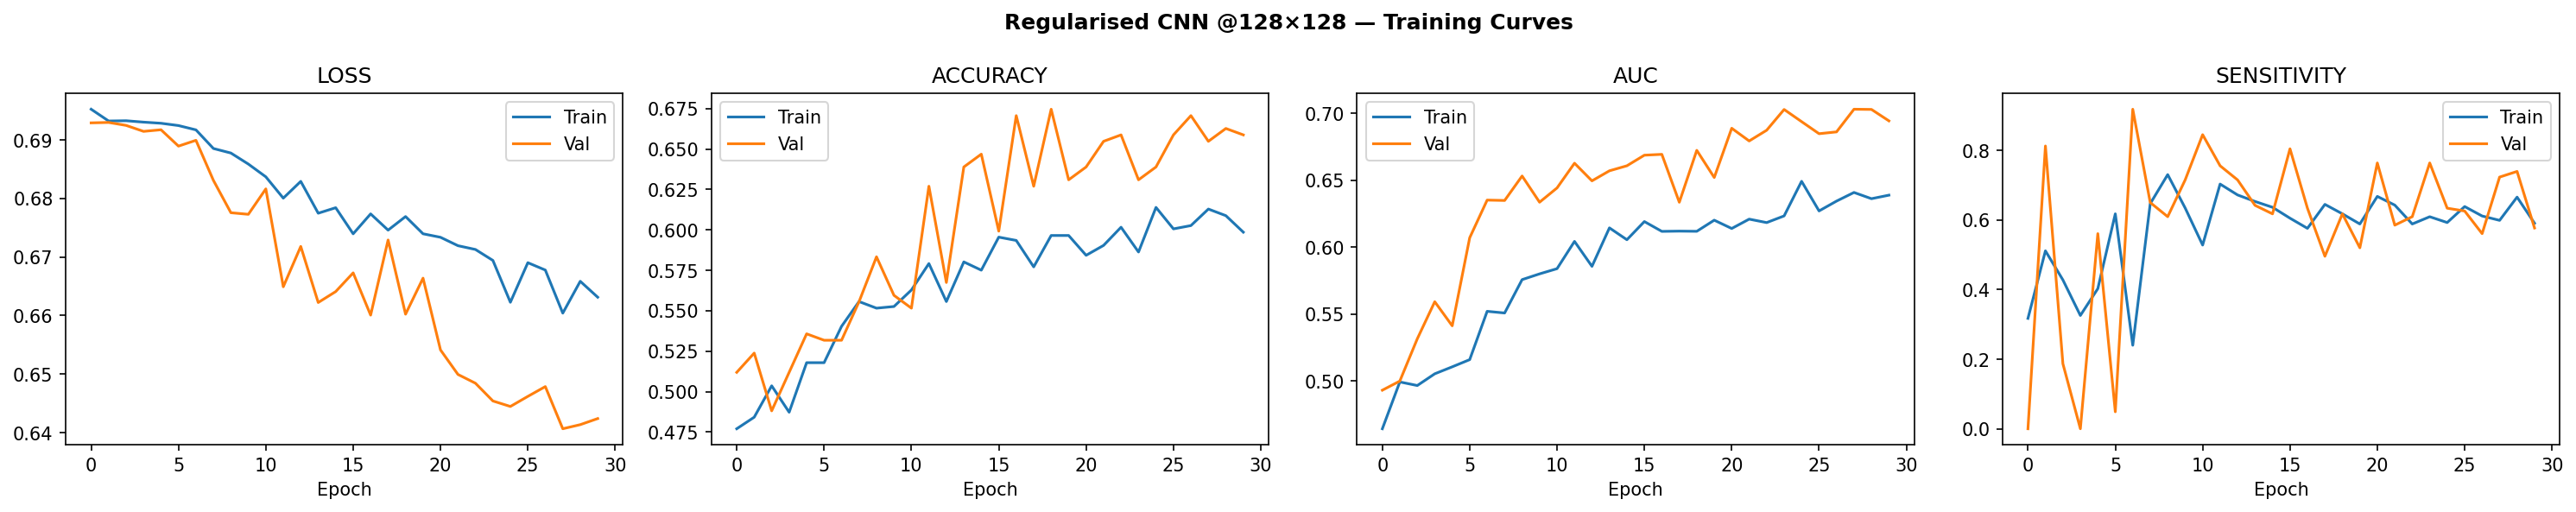

In [13]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_reg128.png"))

### Section 13.4: Regularisation Ablation Comparison

The four 128×128 configurations are compared using validation performance. This comparison shows the individual and combined effects of dropout and data augmentation across the evaluation metrics.

In [21]:
# Validation ablation comparison

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# Best saved model checkpoints

model_paths = {
    "Baseline": os.path.join(MODELS_DIR, "baseline_cnn_best.keras"),
    "Dropout Only": os.path.join(MODELS_DIR, "cnn_dropout_only_best.keras"),
    "Augmentation Only": os.path.join(MODELS_DIR, "cnn_augmentation_only_best.keras"),
    "Dropout + Augmentation": os.path.join(
        MODELS_DIR, "regularised_cnn_128_best.keras"
    ),
}


# Load saved models

models = {
    name: tf.keras.models.load_model(path, compile=False)
    for name, path in model_paths.items()
}

print("All ablation models loaded.")


# Validation labels

y_val = np.concatenate([y.numpy().reshape(-1) for _, y in val_ds_128]).astype(int)


# Validation evaluation

results = []

for name, model in models.items():

    y_prob = model.predict(val_ds_128, verbose=0).reshape(-1)

    # Threshold selected using VALIDATION only
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)

    j_scores = tpr - fpr

    best_idx = np.argmax(j_scores)

    threshold = float(thresholds[best_idx])

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    results.append(
        {
            "Configuration": name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Sensitivity": recall_score(y_val, y_pred),
            "Specificity": (tn / (tn + fp)),
            "Precision": precision_score(y_val, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_val, y_prob),
        }
    )


# Validation results table

validation_results = pd.DataFrame(results)

print("\nVALIDATION ABLATION COMPARISON")
print("=" * 60)

display(validation_results.round(4))

All ablation models loaded.



VALIDATION ABLATION COMPARISON


,Configuration,Threshold,Accuracy,Sensitivity,Specificity,Precision,AUC
0,Baseline,0.5308,0.6667,0.6341,0.6977,0.6667,0.6938
1,Dropout Only,0.5249,0.6548,0.5285,0.7752,0.6915,0.6818
2,Augmentation Only,0.5010,0.6508,0.6667,0.6357,0.6357,0.6812
3,Dropout + Augmentation,0.5384,0.6865,0.6098,0.7597,0.7075,0.7032


## Section 14: Input Resolution Experiment - 128×128 vs 224×224

The regularised/scaled custom CNN is evaluated at both **128×128** and **224×224** resolution using the same modelling strategy. This experiment examines whether retaining greater image detail through increased input resolution improves validation performance.

The 224×224 configuration did not outperform the 128×128 model, indicating that increased resolution alone was not beneficial in this experiment.

In [12]:
# Regularised/scaled CNN architecture (32-64-128-256 filters, dense 256, dropout 0.5)


def build_regularised_scaled_cnn(img_size, name="Regularised_Scaled_CNN"):

    model = tf.keras.Sequential(
        [
            layers.Input(shape=(img_size, img_size, 3)),
            layers.Conv2D(32, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            # Added scaled-up convolutional block
            layers.Conv2D(256, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.GlobalAveragePooling2D(),
            # Increased dense representation
            layers.Dense(256, activation="relu"),
            # Regularisation
            layers.Dropout(0.5),
            layers.Dense(1, activation="sigmoid"),
        ],
        name=name,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    return model


build_regularised_scaled_cnn(IMG_SIZE_128).summary()

Model: "Regularised_Scaled_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,465 (1.73 MB)

 Trainable params: 454,465 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Regularised/scaled CNN at 128x128

reg128_model = build_regularised_scaled_cnn(
    IMG_SIZE_128, name="Regularised_Scaled_CNN_128"
)

reg128_history, reg128_best_epoch = train_model(
    reg128_model,
    train_ds_128_aug,
    val_ds_128,
    checkpoint_path=(f"{MODELS_DIR}/regularised_scaled_cnn_128_best.keras"),
    class_weight=class_weights,
)

In [ ]:
# Resolution experiment: regularised/scaled CNN at 224x224

reg224_model = build_regularised_scaled_cnn(
    IMG_SIZE_224, name="Regularised_Scaled_CNN_224"
)

reg224_history, reg224_best_epoch = train_model(
    reg224_model,
    train_ds_224_aug,
    val_ds_224,
    checkpoint_path=(f"{MODELS_DIR}/regularised_scaled_cnn_224_best.keras"),
    class_weight=class_weights,
)

Regularised scaled CNN models loaded.
Optimal threshold (Youden's J): 0.557  (val sensitivity=0.862, val specificity=0.535)

Regularised Scaled CNN (128px) — Validation Results (threshold=0.557)
              precision    recall  f1-score   support

      Benign       0.80      0.53      0.64       129
   Malignant       0.64      0.86      0.73       123

    accuracy                           0.69       252
   macro avg       0.72      0.70      0.69       252
weighted avg       0.72      0.69      0.69       252

Accuracy    : 0.6944
Sensitivity : 0.8618  (missed 17 of 123 malignant cases)
Specificity : 0.5349
Precision   : 0.6386
AUC         : 0.7353


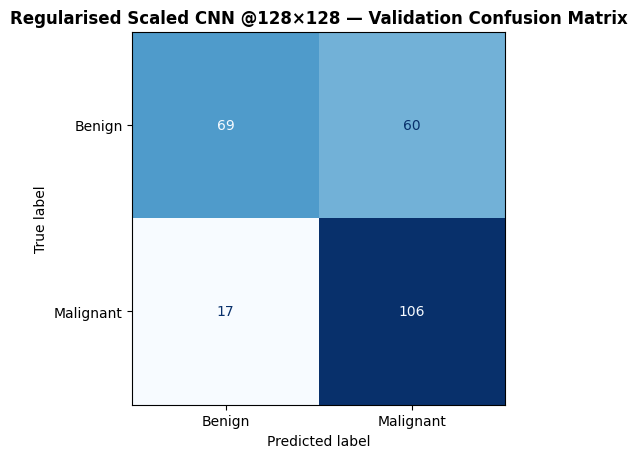

Optimal threshold (Youden's J): 0.469  (val sensitivity=0.829, val specificity=0.504)

Regularised Scaled CNN (224px) — Validation Results (threshold=0.469)
              precision    recall  f1-score   support

      Benign       0.76      0.50      0.60       129
   Malignant       0.61      0.83      0.71       123

    accuracy                           0.66       252
   macro avg       0.69      0.67      0.66       252
weighted avg       0.69      0.66      0.65       252

Accuracy    : 0.6627
Sensitivity : 0.8293  (missed 21 of 123 malignant cases)
Specificity : 0.5039
Precision   : 0.6145
AUC         : 0.6856


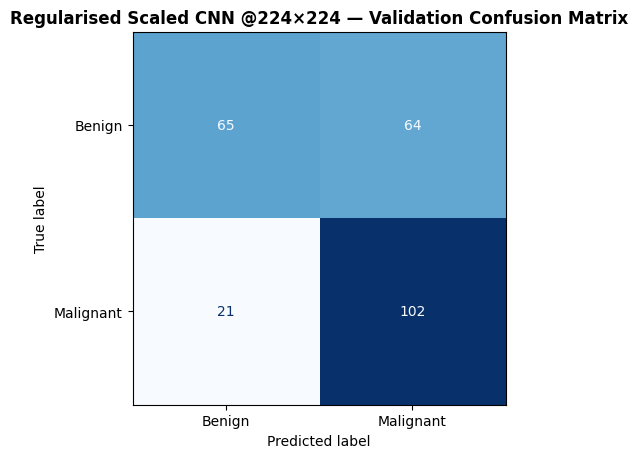


VALIDATION RESOLUTION COMPARISON


,model,threshold,accuracy,sensitivity,specificity,precision,auc
0,Regularised Scaled CNN (128px),0.5567,0.6944,0.8618,0.5349,0.6386,0.7353
1,Regularised Scaled CNN (224px),0.4690,0.6627,0.8293,0.5039,0.6145,0.6856


In [23]:
# Resolution comparison on validation set (no retraining needed)

import pandas as pd
import tensorflow as tf

# Load best saved models

reg128_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/regularised_scaled_cnn_128_best.keras", compile=False
)

reg224_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/regularised_scaled_cnn_224_best.keras", compile=False
)

print("Regularised scaled CNN models loaded.")


# 128x128 validation evaluation

reg128_threshold = find_best_threshold(reg128_model, val_ds_128)

reg128_results = evaluate_model(
    reg128_model,
    val_ds_128,
    name="Regularised Scaled CNN (128px)",
    threshold=reg128_threshold,
    split_name="Validation",
)

plot_confusion_matrix(
    reg128_results["cm"],
    "Regularised Scaled CNN @128×128 - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_reg_scaled_128_validation.png",
)


# 224x224 validation evaluation

reg224_threshold = find_best_threshold(reg224_model, val_ds_224)

reg224_results = evaluate_model(
    reg224_model,
    val_ds_224,
    name="Regularised Scaled CNN (224px)",
    threshold=reg224_threshold,
    split_name="Validation",
)

plot_confusion_matrix(
    reg224_results["cm"],
    "Regularised Scaled CNN @224×224 - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_reg_scaled_224_validation.png",
)


# Resolution comparison

resolution_comparison = pd.DataFrame([reg128_results, reg224_results])[
    ["model", "threshold", "accuracy", "sensitivity", "specificity", "precision", "auc"]
]

print("\nVALIDATION RESOLUTION COMPARISON")
print("=" * 60)

display(resolution_comparison.round(4))

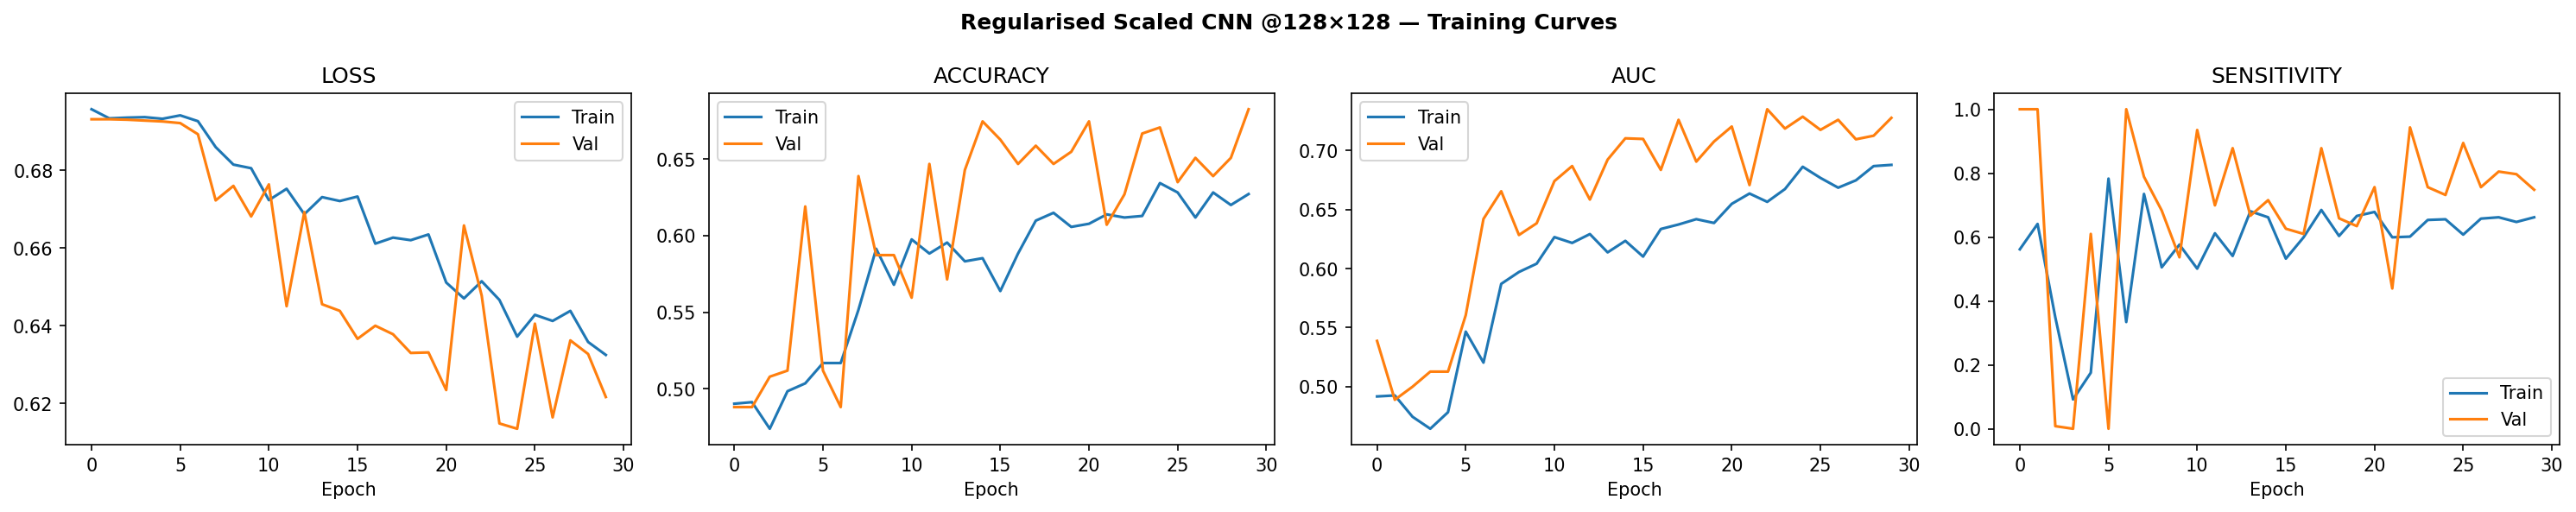

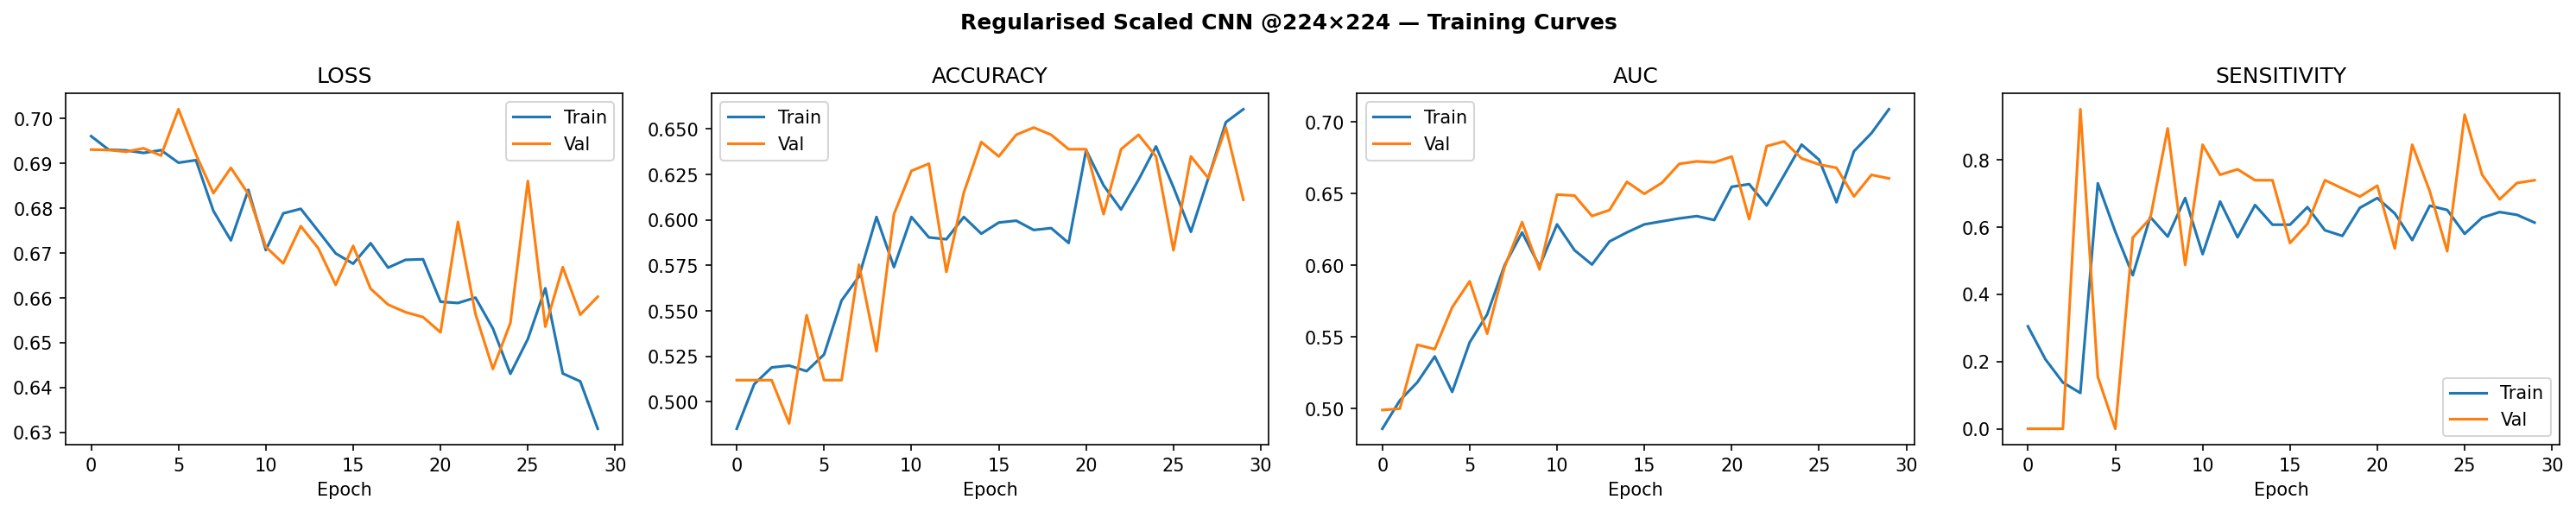

In [14]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_reg_scaled_128.png"))

display(Image(filename=f"{BASE}/curves_reg_scaled_224.png"))

## Section 15: Grad-CAM - Regularised/Scaled CNNs

Grad-CAM visualisations are generated for the regularised/scaled CNN at both input resolutions. These provide a qualitative view of the image regions influencing predictions and complement the validation-based resolution comparison.

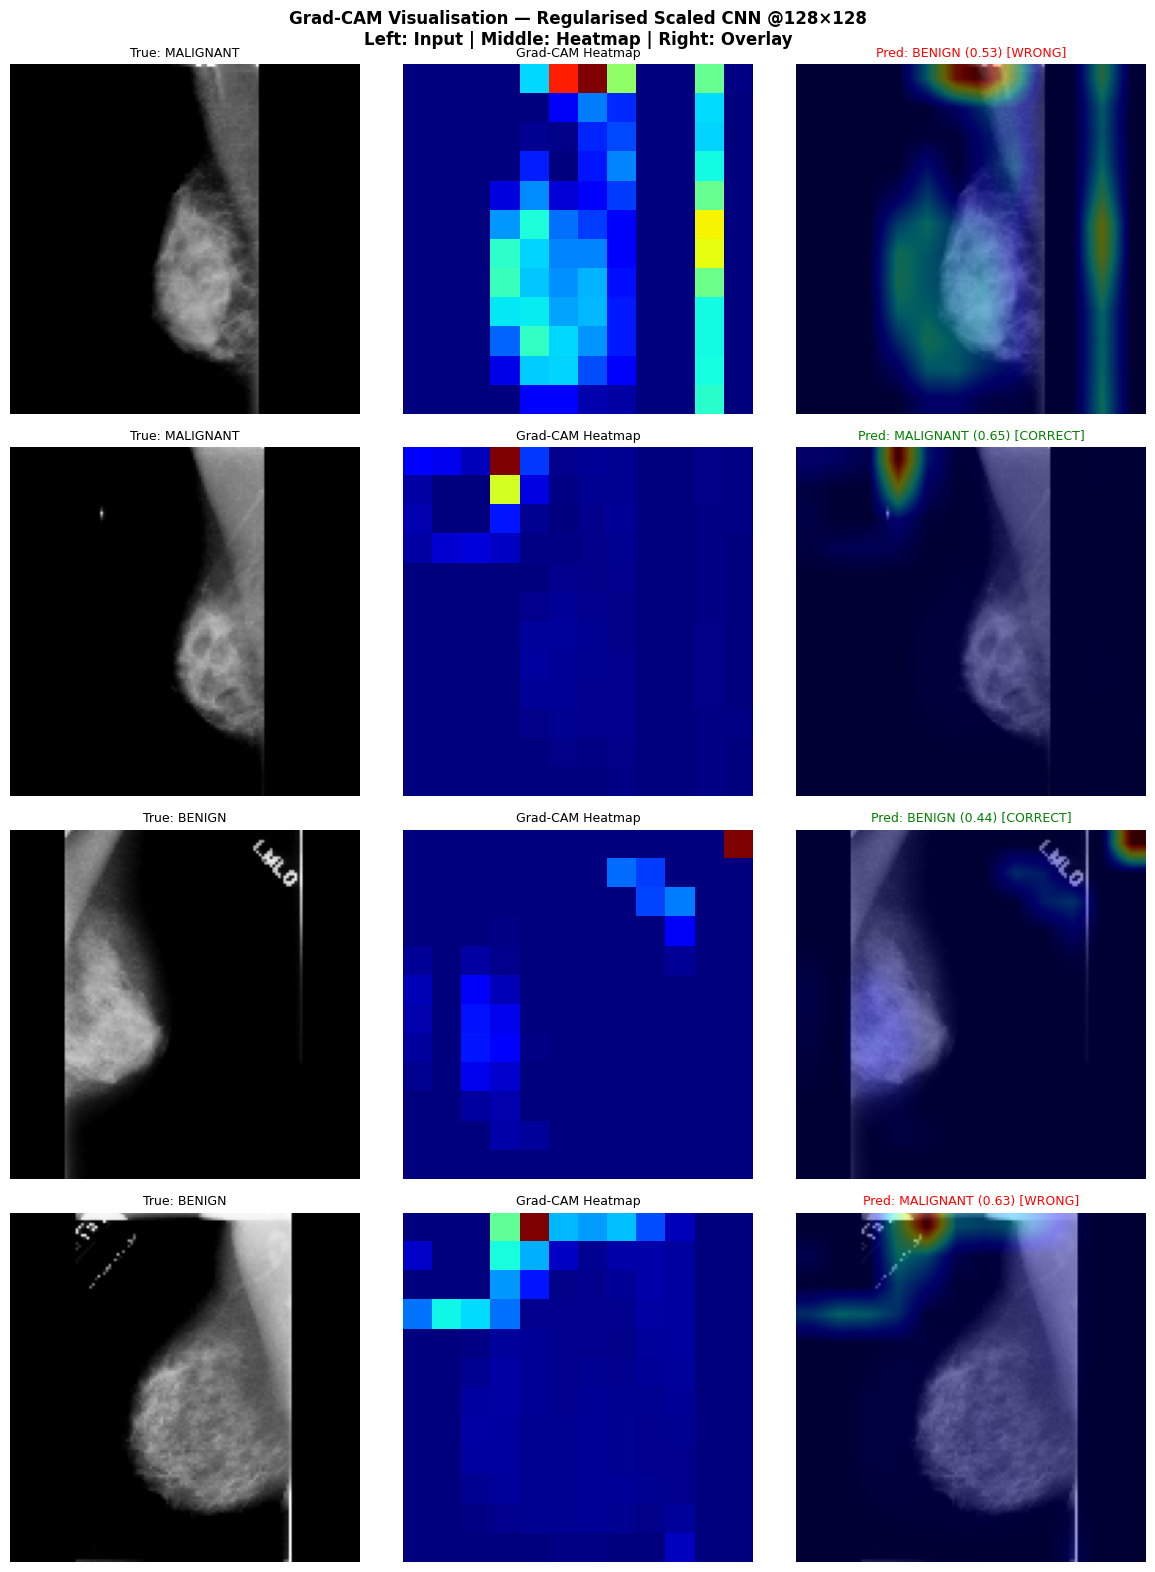

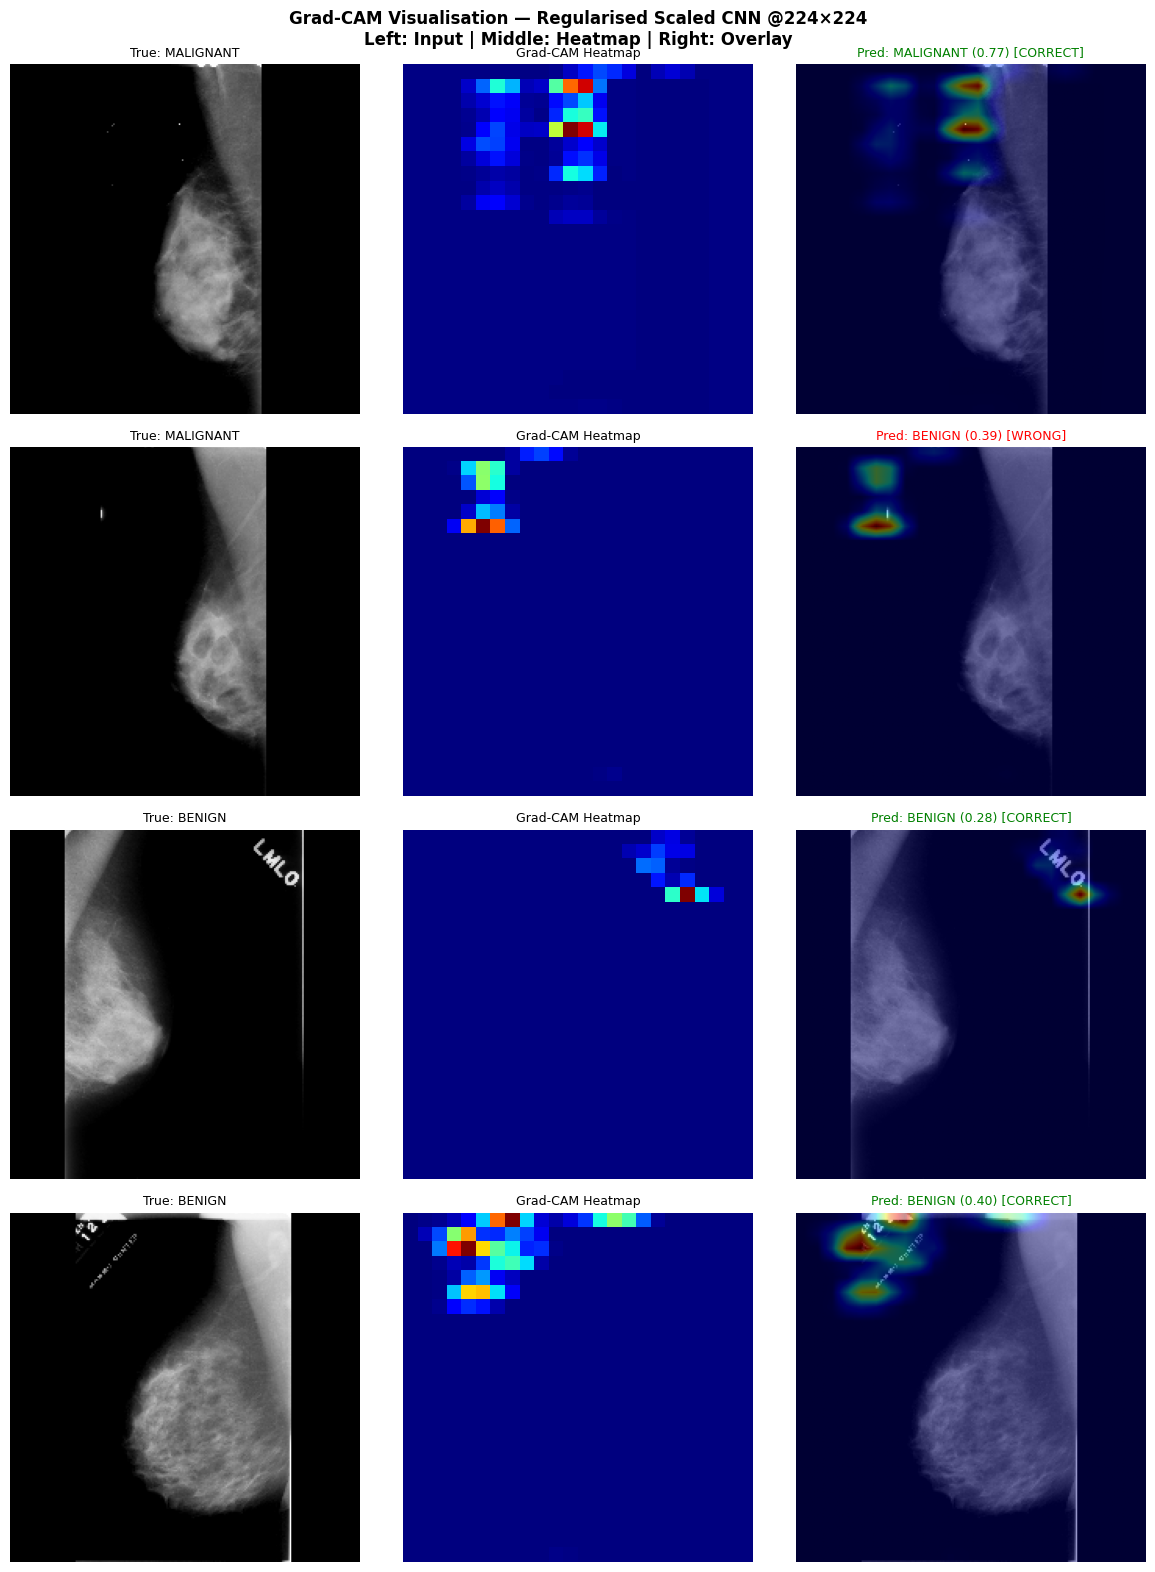

In [24]:
# Grad-CAM: regularised/scaled CNN

plot_gradcam_grid(
    reg128_model,
    "Regularised Scaled CNN @128×128",
    IMG_SIZE_128,
    threshold=reg128_threshold,
    save_path=f"{BASE}/gradcam_reg_scaled_128.png",
)

plot_gradcam_grid(
    reg224_model,
    "Regularised Scaled CNN @224×224",
    IMG_SIZE_224,
    threshold=reg224_threshold,
    save_path=f"{BASE}/gradcam_reg_scaled_224.png",
)

## Section 16: Custom CNN Stage Comparison

The main custom CNN configurations are compared using validation performance: the **baseline CNN**, **regularised/scaled CNN at 128×128**, and **regularised/scaled CNN at 224×224**.

This summarises the development of the custom CNN before progressing to pretrained transfer-learning models.

In [25]:
# Stage comparison: baseline vs regularised CNN (128 vs 224)

# Reload the principal baseline model
baseline_principal_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/baseline_cnn_best.keras", compile=False
)

# Validation-derived threshold
baseline_principal_threshold = find_best_threshold(baseline_principal_model, val_ds_128)

# Validation evaluation
baseline_principal_results = evaluate_model(
    baseline_principal_model,
    val_ds_128,
    name="Baseline CNN (128px)",
    threshold=baseline_principal_threshold,
    split_name="Validation",
    verbose=False,
)

# Compare development stages using VALIDATION only
stage_comparison = pd.DataFrame(
    [baseline_principal_results, reg128_results, reg224_results]
)[["model", "accuracy", "sensitivity", "specificity", "precision", "auc"]]

display(stage_comparison.round(4))

Optimal threshold (Youden's J): 0.531  (val sensitivity=0.634, val specificity=0.698)


,model,accuracy,sensitivity,specificity,precision,auc
0,Baseline CNN (128px),0.6667,0.6341,0.6977,0.6667,0.6938
1,Regularised Scaled CNN (128px),0.6944,0.8618,0.5349,0.6386,0.7353
2,Regularised Scaled CNN (224px),0.6627,0.8293,0.5039,0.6145,0.6856


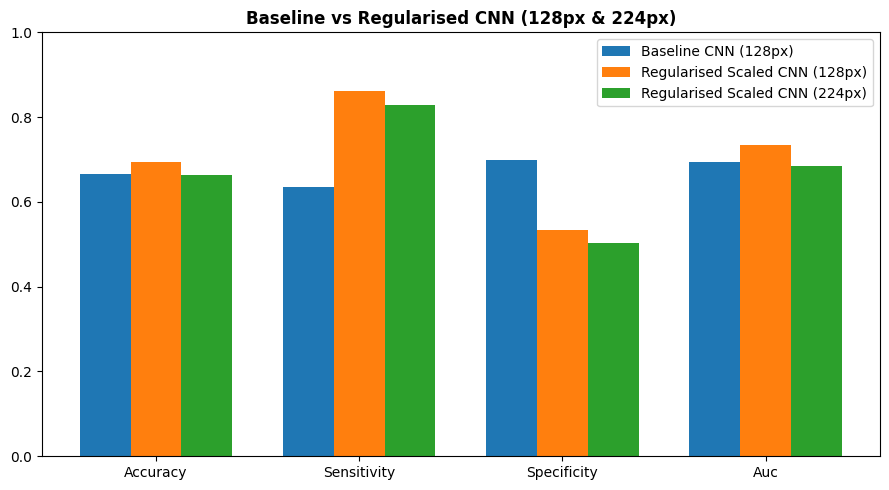

In [26]:
# Stage comparison bar chart

fig, ax = plt.subplots(figsize=(9, 5))

metrics_to_plot = ["accuracy", "sensitivity", "specificity", "auc"]

x = np.arange(len(metrics_to_plot))
width = 0.25

for i, row in stage_comparison.iterrows():

    ax.bar(x + i * width, [row[m] for m in metrics_to_plot], width, label=row["model"])

ax.set_xticks(x + width)

ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])

ax.set_ylim(0, 1)

ax.set_title("Baseline vs Regularised CNN (128px & 224px)", fontweight="bold")

ax.legend()

plt.tight_layout()

plt.savefig(f"{BASE}/comparison_stage2.png", dpi=150, bbox_inches="tight")

plt.show()

## Section 17: Transfer Learning - Build and Fine-Tune Strategy

Transfer learning is investigated using **VGG16** and **ResNet50** pretrained on ImageNet. Each model uses a classification head with global average pooling, a dense layer, dropout and a sigmoid output.

Training follows two stages: initial feature extraction with the pretrained base frozen, followed by selective fine-tuning of the upper layers using a lower learning rate. Model-specific ImageNet preprocessing is applied to each architecture.

In [14]:
def prepare_vgg_dataset(ds):
    # VGG16 expects its ImageNet preprocessing, not plain 0-1 inputs
    return ds.map(
        lambda images, labels: (vgg16_preprocess(images * 255.0), labels),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)


def prepare_resnet_dataset(ds):
    # ResNet50 uses its own ImageNet preprocessing
    return ds.map(
        lambda images, labels: (resnet50_preprocess(images * 255.0), labels),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)


# Model-specific datasets keep the same samples and labels
vgg_train_ds = prepare_vgg_dataset(train_ds_224_aug)
vgg_val_ds = prepare_vgg_dataset(val_ds_224)
vgg_test_ds = prepare_vgg_dataset(test_ds_224)

resnet_train_ds = prepare_resnet_dataset(train_ds_224_aug)
resnet_val_ds = prepare_resnet_dataset(val_ds_224)
resnet_test_ds = prepare_resnet_dataset(test_ds_224)


def build_transfer_model(base_class, img_size=IMG_SIZE_224, name="transfer_model"):
    base_model = base_class(
        weights="imagenet", include_top=False, input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # frozen for Stage A

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    return model, base_model


def fine_tune(model, base_model, unfreeze_fraction=0.3):
    # Unfreeze the top part of the pretrained model
    base_model.trainable = True
    n_layers = len(base_model.layers)
    freeze_until = int(n_layers * (1 - unfreeze_fraction))

    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    print(f"Unfroze top {n_layers - freeze_until} of {n_layers} base layers.")
    return model


def run_transfer_learning(
    base_class, model_name, checkpoint_prefix, train_ds, val_ds, class_weight=None
):
    print(f"\n{'='*60}\n{model_name} - Stage A: frozen head (10 epochs)\n{'='*60}")

    model, base_model = build_transfer_model(base_class, IMG_SIZE_224, name=model_name)

    head_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1,
        class_weight=class_weight,
    )

    print(f"\n{'='*60}\n{model_name} - Stage B: fine-tuning (lr=1e-5)\n{'='*60}")

    model = fine_tune(model, base_model)

    ft_callbacks = [
        EarlyStopping(
            monitor="val_auc",
            patience=7,
            restore_best_weights=True,
            mode="max",
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=f"{MODELS_DIR}/{checkpoint_prefix}_best.keras",
            monitor="val_auc",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
    ]

    ft_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=ft_callbacks,
        verbose=1,
        class_weight=class_weight,
    )

    combined_history = {
        k: head_history.history[k] + ft_history.history[k] for k in head_history.history
    }

    model.save(f"{MODELS_DIR}/{checkpoint_prefix}_final.keras")
    return model, combined_history


print("Transfer learning helpers ready.")

Transfer learning helpers ready.


## Section 18: Transfer Learning - VGG16

VGG16 is trained using ImageNet-pretrained weights and VGG16-specific preprocessing. Following staged training and fine-tuning, the best saved checkpoint is evaluated on the validation set using a validation-derived decision threshold.

In [77]:
# Train VGG16 using VGG16 ImageNet preprocessing
vgg_model, vgg_history = run_transfer_learning(
    VGG16,
    "VGG16",
    "vgg16",
    train_ds=vgg_train_ds,
    val_ds=vgg_val_ds,
    class_weight=class_weights,
)


VGG16 — Stage A: frozen head (10 epochs)
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 382ms/step - accuracy: 0.5128 - auc: 0.4968 - loss: 1.2022 - precision: 0.5021 - sensitivity: 0.5094 - val_accuracy: 0.5357 - val_auc: 0.6256 - val_loss: 0.7978 - val_precision: 0.5133 - val_sensitivity: 0.9431
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.5434 - auc: 0.5696 - loss: 0.7851 - precision: 0.5308 - sensitivity: 0.5762 - val_accuracy: 0.6071 - val_auc: 0.6529 - val_loss: 0.6633 - val_precision: 0.6463 - val_sensitivity: 0.4309
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.5914 - auc: 0.6195 - loss: 0.6759 - precision: 0.5738 - sensitivity: 0.6409 - val_accuracy: 0.5794 - val_auc: 0.6438 - val_loss: 0.6607 - val_precision: 0.5876 - val_sensitivity: 0.4634
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.6067 - auc: 0.6581 - loss: 0.6598 - precision: 0.6049 - sensitivity: 0.5658 - val_accuracy: 0.6389 - val_auc: 0.6948 - val_loss: 0.6542

Optimal threshold (Youden's J): 0.317  (val sensitivity=0.764, val specificity=0.744)

VGG16 — Validation Results (threshold=0.317)
              precision    recall  f1-score   support

      Benign       0.77      0.74      0.76       129
   Malignant       0.74      0.76      0.75       123

    accuracy                           0.75       252
   macro avg       0.75      0.75      0.75       252
weighted avg       0.75      0.75      0.75       252

Accuracy    : 0.754
Sensitivity : 0.7642  (missed 29 of 123 malignant cases)
Specificity : 0.7442
Precision   : 0.7402
AUC         : 0.8254


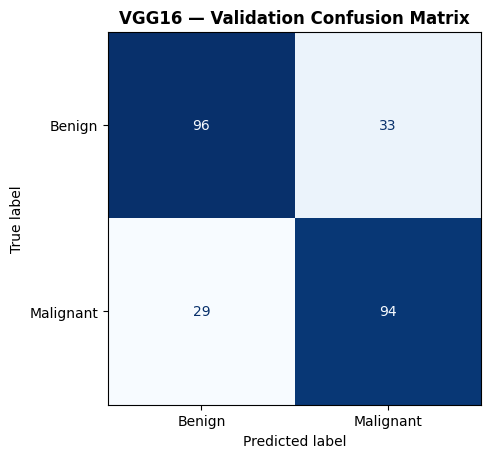

In [30]:
vgg_model = tf.keras.models.load_model(f"{MODELS_DIR}/vgg16_best.keras", compile=False)

vgg_threshold = find_best_threshold(vgg_model, vgg_val_ds)

vgg_results = evaluate_model(
    vgg_model,
    vgg_val_ds,
    name="VGG16",
    threshold=vgg_threshold,
    split_name="Validation",
)

plot_confusion_matrix(
    vgg_results["cm"],
    "VGG16 - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_vgg16_validation.png",
)

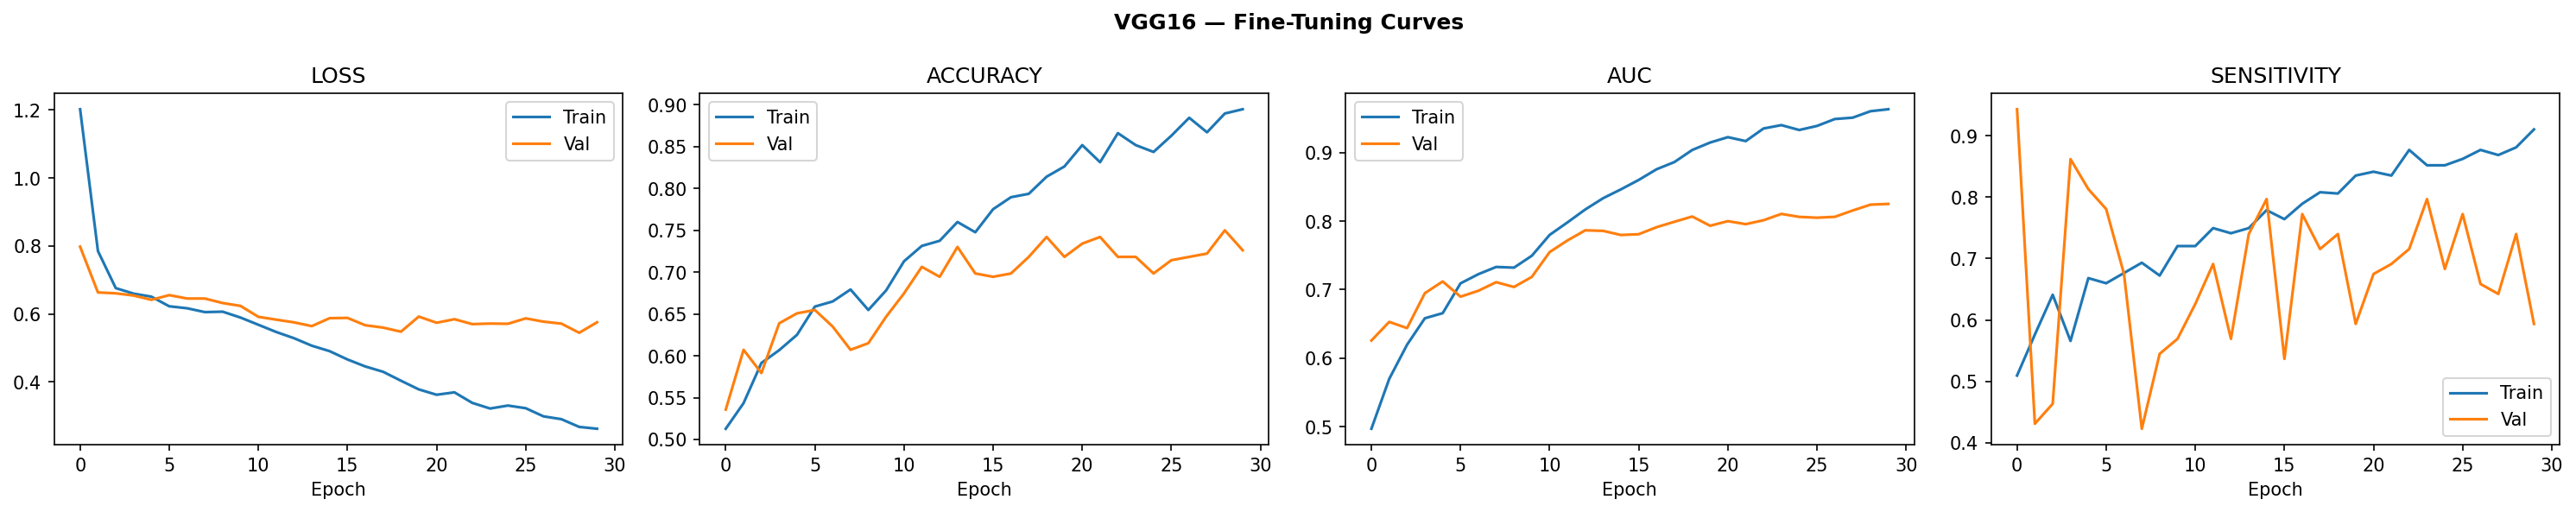

In [15]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_vgg16.png"))

## Section 19: Transfer Learning - ResNet50

ResNet50 is trained using ImageNet-pretrained weights and ResNet50-specific preprocessing. The same two-stage transfer-learning strategy is used before evaluating the best checkpoint on the validation set.

In [79]:
# Train ResNet50 using ResNet50 ImageNet preprocessing
resnet_model, resnet_history = run_transfer_learning(
    ResNet50,
    "ResNet50",
    "resnet50",
    train_ds=resnet_train_ds,
    val_ds=resnet_val_ds,
    class_weight=class_weights,
)


ResNet50 — Stage A: frozen head (10 epochs)
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 510ms/step - accuracy: 0.4944 - auc: 0.4874 - loss: 0.7759 - precision: 0.4822 - sensitivity: 0.4530 - val_accuracy: 0.5278 - val_auc: 0.6024 - val_loss: 0.6925 - val_precision: 1.0000 - val_sensitivity: 0.0325
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.5465 - auc: 0.5662 - loss: 0.6864 - precision: 0.5308 - sensitivity: 0.6305 - val_accuracy: 0.5476 - val_auc: 0.5935 - val_loss: 0.6830 - val_precision: 0.6800 - val_sensitivity: 0.1382
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.5536 - auc: 0.5721 - loss: 0.6857 - precision: 0.5469 - sensitivity: 0.5115 - val_accuracy: 0.5476 - val_auc: 0.6157 - val_loss: 0.6824 - val_precision: 0.6667 - val_sensitivity: 0.1463
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.5424 - auc: 0.5718 - loss: 0.6844 - precision: 0.5336 - sensitivity: 0.5136 - val_accuracy: 0.5516 - val_auc: 0.5838 - val_loss: 0.6

Optimal threshold (Youden's J): 0.381  (val sensitivity=0.919, val specificity=0.504)

ResNet50 — Validation Results (threshold=0.381)
              precision    recall  f1-score   support

      Benign       0.87      0.50      0.64       129
   Malignant       0.64      0.92      0.75       123

    accuracy                           0.71       252
   macro avg       0.75      0.71      0.70       252
weighted avg       0.76      0.71      0.69       252

Accuracy    : 0.7063
Sensitivity : 0.9187  (missed 10 of 123 malignant cases)
Specificity : 0.5039
Precision   : 0.6384
AUC         : 0.7751


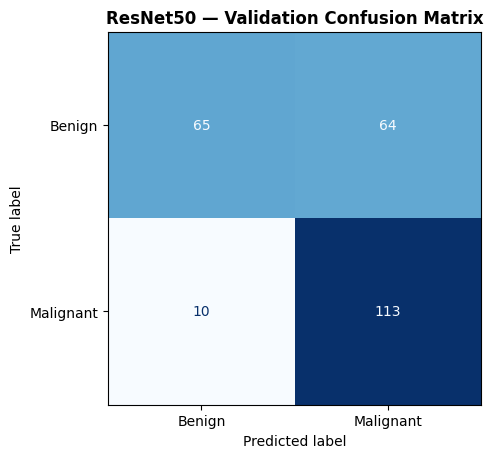

In [31]:
resnet_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_best.keras", compile=False
)

resnet_threshold = find_best_threshold(resnet_model, resnet_val_ds)

resnet_results = evaluate_model(
    resnet_model,
    resnet_val_ds,
    name="ResNet50",
    threshold=resnet_threshold,
    split_name="Validation",
)

plot_confusion_matrix(
    resnet_results["cm"],
    "ResNet50 - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_resnet50_validation.png",
)

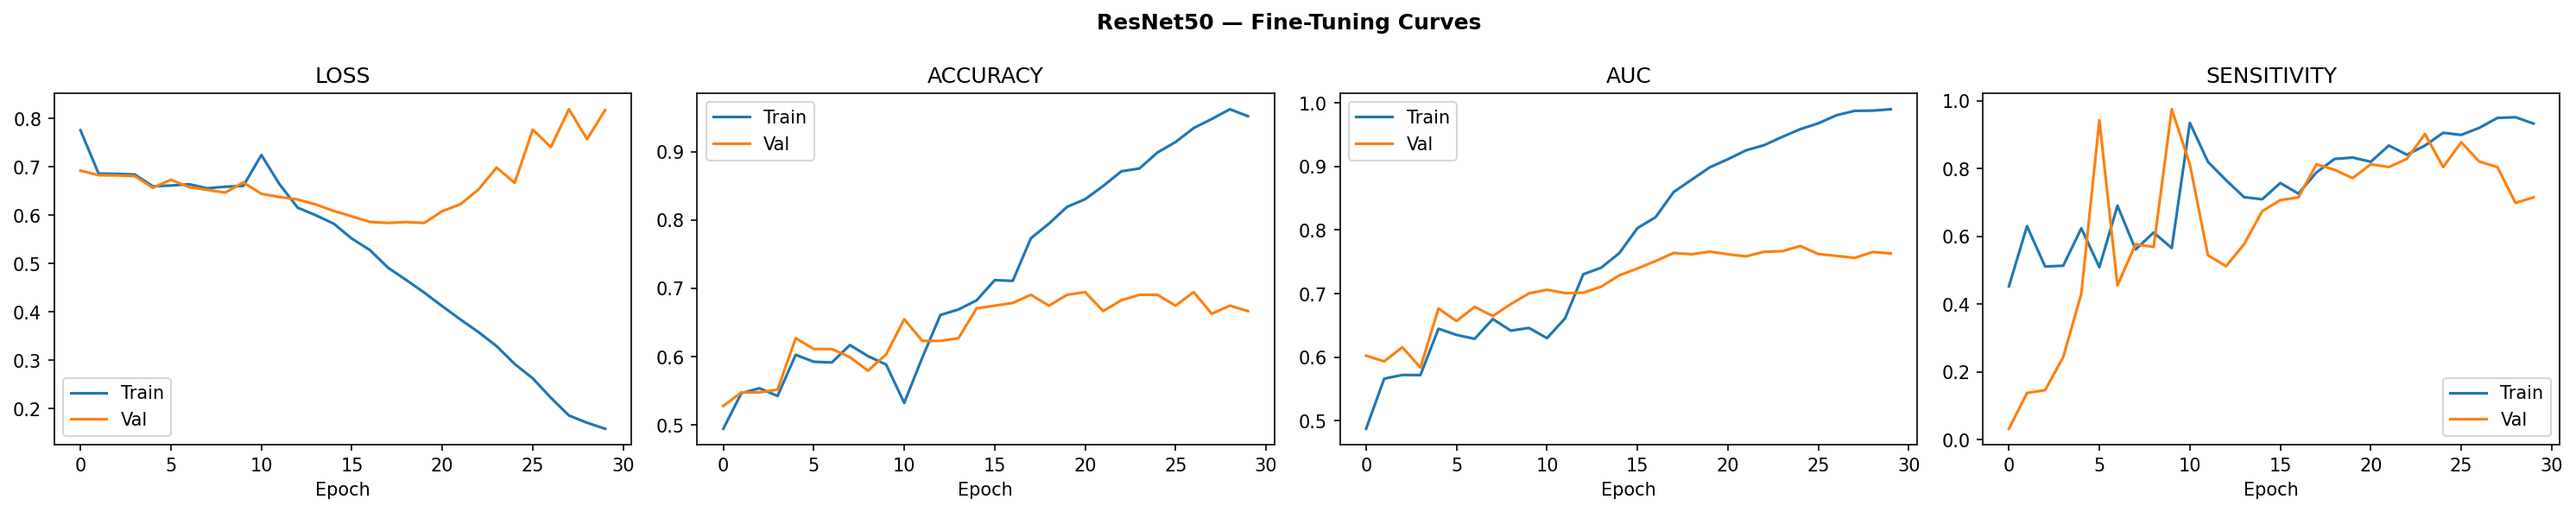

In [16]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_resnet50.png"))

## Section 20: Grad-CAM - VGG16 and ResNet50

Grad-CAM visualisations are generated for VGG16 and ResNet50 to examine the image regions contributing to their predictions. This provides qualitative interpretability evidence alongside their validation performance.

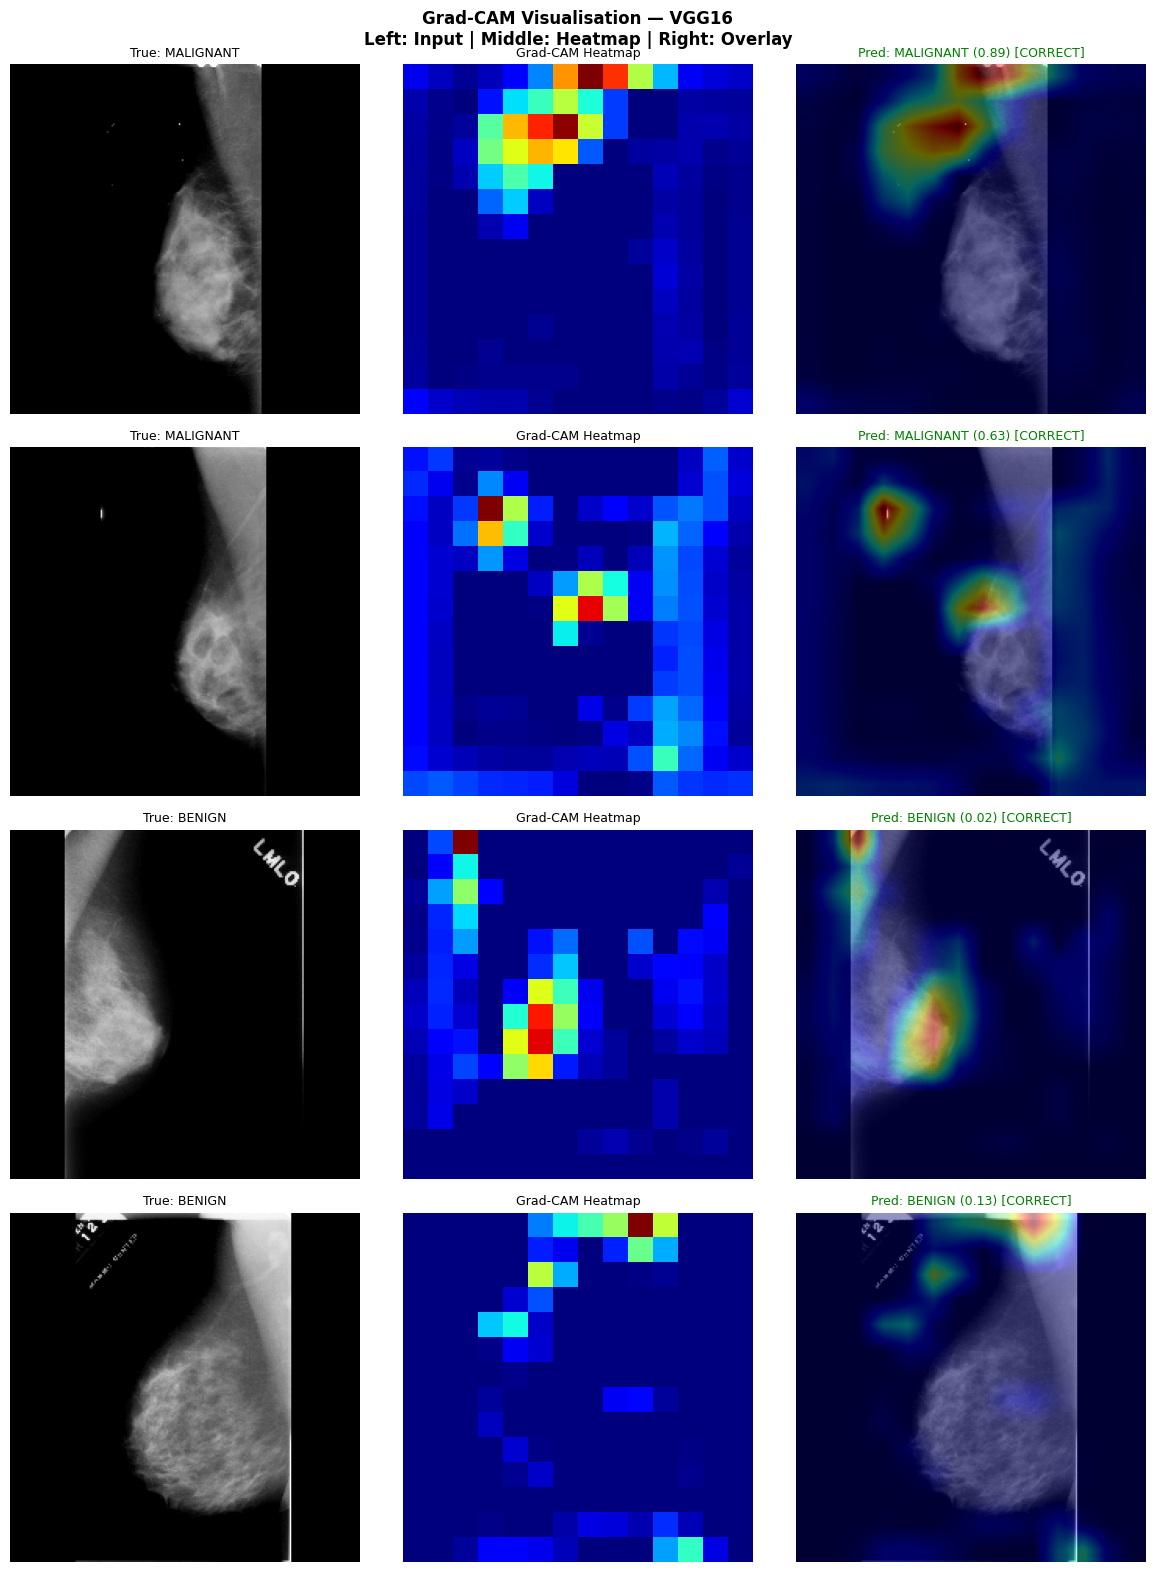

In [32]:
# Grad-CAM uses the same VGG16 preprocessing as evaluation
plot_gradcam_grid(
    vgg_model,
    "VGG16",
    IMG_SIZE_224,
    threshold=vgg_threshold,
    model_type="vgg16",
    save_path=f"{BASE}/gradcam_vgg16.png",
)

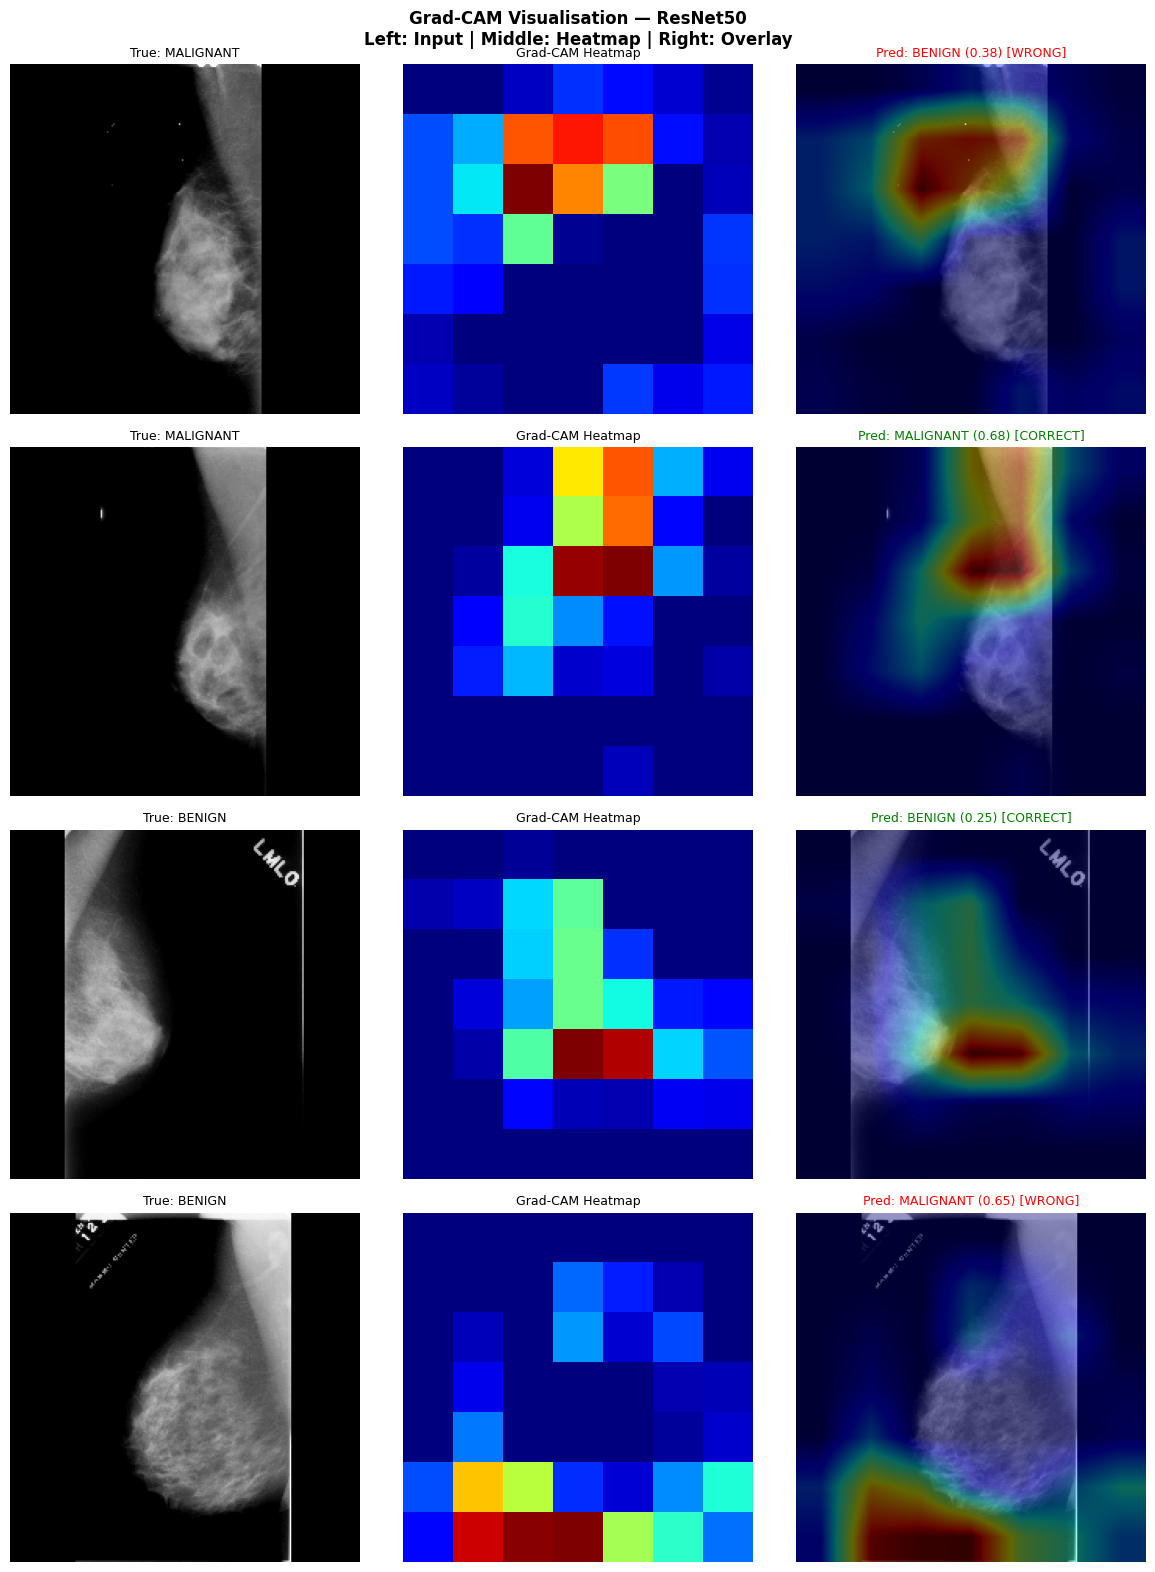

In [33]:
# Grad-CAM uses the same ResNet50 preprocessing as evaluation
plot_gradcam_grid(
    resnet_model,
    "ResNet50",
    IMG_SIZE_224,
    threshold=resnet_threshold,
    model_type="resnet50",
    save_path=f"{BASE}/gradcam_resnet50.png",
)

## Section 21: Pre-CLAHE Model Comparison

The models developed so far are compared using validation metrics before introducing CLAHE preprocessing. This provides a common reference for assessing the custom CNN and transfer-learning approaches.

In [34]:
# Principal model comparison (uses the baseline model, not the scaling one)

all_results = pd.DataFrame(
    [
        baseline_principal_results,
        reg128_results,
        reg224_results,
        vgg_results,
        resnet_results,
    ]
)[["model", "threshold", "accuracy", "sensitivity", "specificity", "precision", "auc"]]

all_results = all_results.sort_values("sensitivity", ascending=False).reset_index(
    drop=True
)

display(all_results)

,model,threshold,accuracy,sensitivity,specificity,precision,auc
0,ResNet50,0.3814,0.7063,0.9187,0.5039,0.6384,0.7751
1,Regularised Scaled CNN (128px),0.5567,0.6944,0.8618,0.5349,0.6386,0.7353
2,Regularised Scaled CNN (224px),0.4690,0.6627,0.8293,0.5039,0.6145,0.6856
3,VGG16,0.3172,0.7540,0.7642,0.7442,0.7402,0.8254
4,Baseline CNN (128px),0.5308,0.6667,0.6341,0.6977,0.6667,0.6938


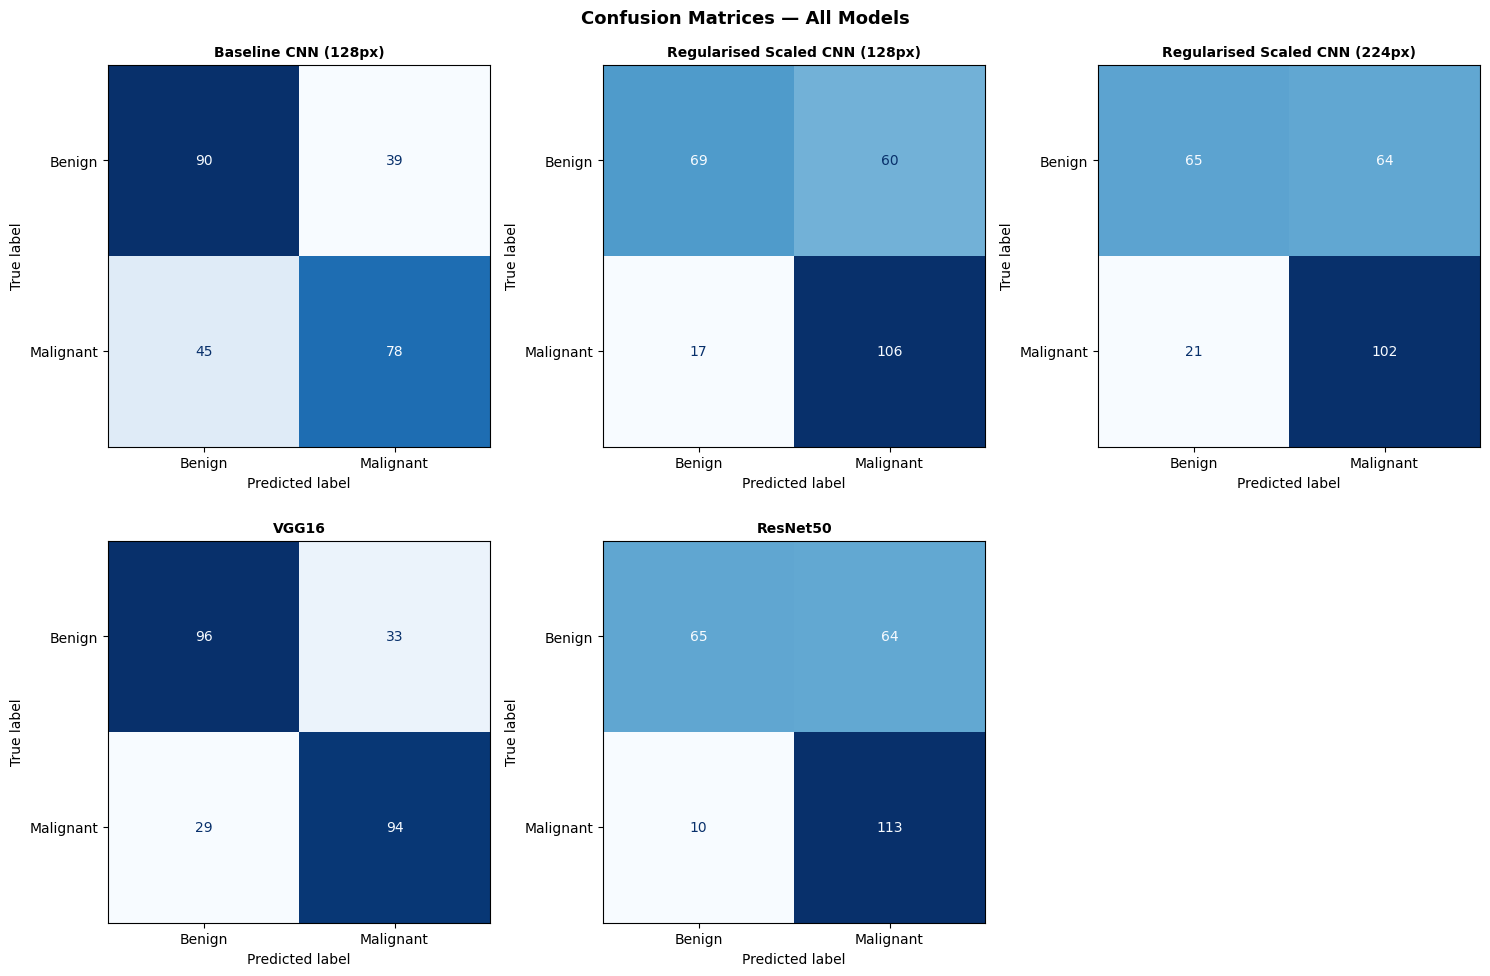

In [35]:
# Confusion matrices for principal models

cms = [
    baseline_principal_results,
    reg128_results,
    reg224_results,
    vgg_results,
    resnet_results,
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, res in zip(axes.flat, cms):

    ConfusionMatrixDisplay(res["cm"], display_labels=["Benign", "Malignant"]).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format="d"
    )

    ax.set_title(res["model"], fontsize=10, fontweight="bold")

axes.flat[-1].axis("off")

plt.suptitle("Confusion Matrices - All Models", fontweight="bold", fontsize=13)

plt.tight_layout()

plt.savefig(f"{BASE}/confusion_matrices_all.png", dpi=150, bbox_inches="tight")

plt.show()

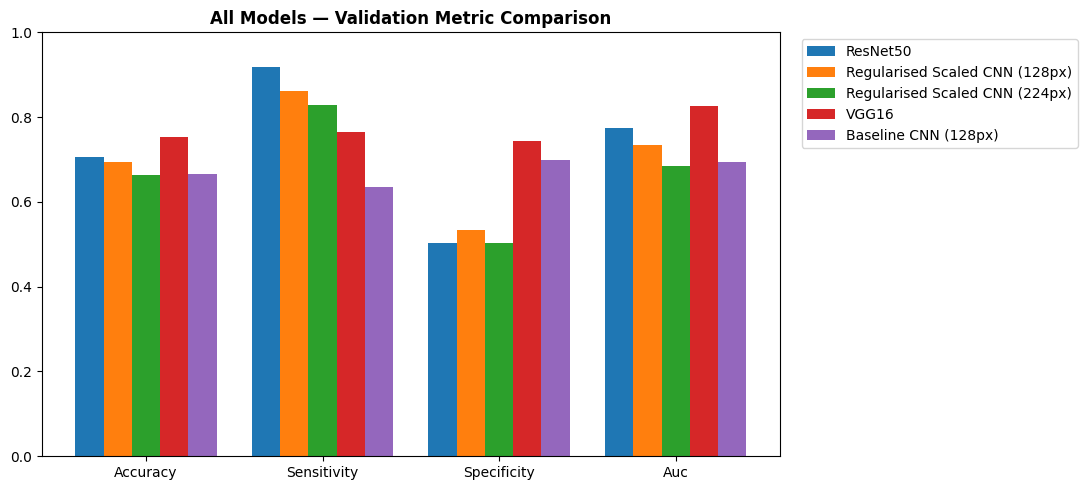

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))

metrics_to_plot = ["accuracy", "sensitivity", "specificity", "auc"]
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(all_results)

for i, row in all_results.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot], width, label=row["model"])

ax.set_xticks(x + width * (len(all_results) - 1) / 2)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.set_ylim(0, 1)
ax.set_title("All Models - Validation Metric Comparison", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(
    f"{BASE}/comparison_all_models_validation.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Section 22: CLAHE Preprocessing for ResNet50

Contrast Limited Adaptive Histogram Equalisation (**CLAHE**) is introduced as a dedicated preprocessing enhancement for ResNet50. CLAHE is applied after cropping to improve local contrast before resizing and ResNet50-specific ImageNet preprocessing.

The original ResNet50 pipeline is otherwise retained to support a controlled comparison.

In [13]:
# CLAHE pipeline with deduplicated caches

import cv2


def apply_clahe(image):
    def _clahe(img):
        img = img.numpy().astype(np.uint8)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = cv2.createCLAHE(2.0, (8, 8)).apply(gray)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB).astype(np.float32)

    out = tf.py_function(_clahe, [image], tf.float32)
    out.set_shape([None, None, 3])
    return out


def preprocess_clahe(image, label, img_size):
    image = apply_clahe(crop_to_content(image))
    image = tf.image.resize_with_pad(image, img_size, img_size)
    return tf.cast(image, tf.float32) / 255.0, label


def build_pipeline_clahe(paths, labels, img_size):
    return (
        tf.data.Dataset.from_tensor_slices((paths, labels))
        .map(load_image, num_parallel_calls=AUTOTUNE)
        .map(lambda x, y: preprocess_clahe(x, y, img_size), num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


def get_dataset_clahe(name, paths, labels, img_size, shuffle=False, augmentation=False):

    cache = f"{name}_{img_size}_clahe_dedup_v1"

    if not os.path.exists(f"{BASE}/{cache}_images.npy"):
        print(f"[{name}@{img_size} CLAHE] building NEW deduplicated cache...")
        cache_dataset(build_pipeline_clahe(paths, labels, img_size), cache)
    else:
        print(f"[{name}@{img_size} CLAHE] reusing corrected cache")

    return load_cached(cache, shuffle, augmentation)


train_ds_224_clahe_plain = get_dataset_clahe(
    "train", X_train, y_train, IMG_SIZE_224, shuffle=True
)

train_ds_224_clahe = get_dataset_clahe(
    "train", X_train, y_train, IMG_SIZE_224, shuffle=True, augmentation=True
)

val_ds_224_clahe = get_dataset_clahe("val", X_val, y_val, IMG_SIZE_224)

test_ds_224_clahe = get_dataset_clahe("test", X_test, y_test, IMG_SIZE_224)

print("\n✓ Corrected CLAHE pipelines ready")
print("✓ NEW CLAHE caches used for train, validation and test")

[train@224 CLAHE] reusing corrected cache
[train@224 CLAHE] reusing corrected cache
[val@224 CLAHE] reusing corrected cache
[test@224 CLAHE] reusing corrected cache

✓ Corrected CLAHE pipelines ready
✓ NEW CLAHE caches used for train, validation and test


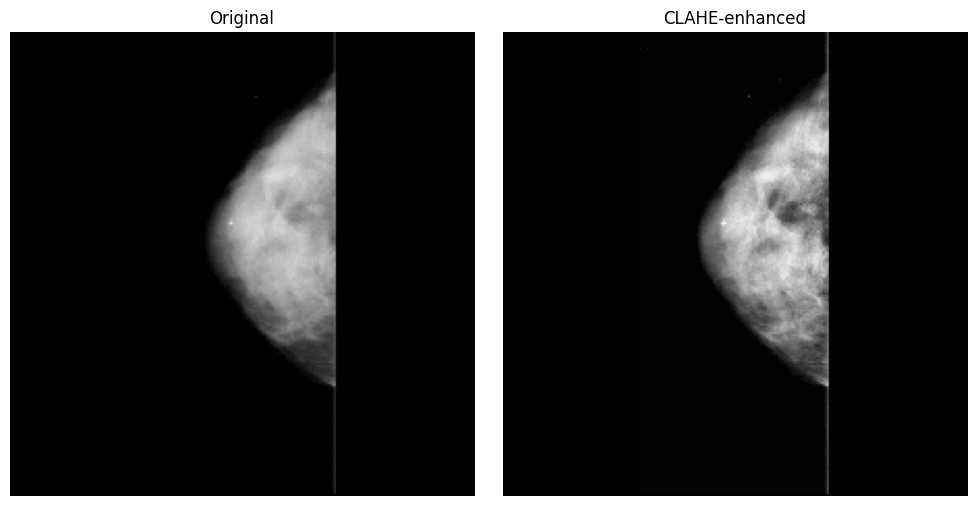

In [29]:
sample_plain = np.load(f"{BASE}/train_224_dedup_v1_images.npy")[0]

sample_clahe = np.load(f"{BASE}/train_224_clahe_dedup_v1_images.npy")[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_plain)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sample_clahe)
axes[1].set_title("CLAHE-enhanced")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Section 23: ResNet50 + CLAHE - Training and Validation Evaluation

ResNet50 is retrained using CLAHE-enhanced mammograms with the same two-stage transfer-learning strategy. The best checkpoint is evaluated on the validation set using a validation-derived decision threshold.

Performance is then compared with plain ResNet50 to assess the effect of CLAHE preprocessing.

In [25]:
# ResNet50 preprocessing after CLAHE
resnet_clahe_train_ds = prepare_resnet_dataset(train_ds_224_clahe)
resnet_clahe_val_ds = prepare_resnet_dataset(val_ds_224_clahe)
resnet_clahe_test_ds = prepare_resnet_dataset(test_ds_224_clahe)


def run_transfer_learning_resnet_clahe(class_weight=None):
    # Same ResNet50 recipe, but with CLAHE inputs
    print(f"\n{'='*60}\nResNet50 + CLAHE - Stage A: frozen head (10 epochs)\n{'='*60}")

    model, base_model = build_transfer_model(
        ResNet50, IMG_SIZE_224, name="ResNet50_CLAHE"
    )

    head_history = model.fit(
        resnet_clahe_train_ds,
        validation_data=resnet_clahe_val_ds,
        epochs=10,
        verbose=1,
        class_weight=class_weight,
    )

    print(f"\n{'='*60}\nResNet50 + CLAHE - Stage B: fine-tuning (lr=1e-5)\n{'='*60}")

    model = fine_tune(model, base_model)

    ft_callbacks = [
        EarlyStopping(
            monitor="val_auc",
            patience=7,
            restore_best_weights=True,
            mode="max",
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=f"{MODELS_DIR}/resnet50_clahe_best.keras",
            monitor="val_auc",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
    ]

    ft_history = model.fit(
        resnet_clahe_train_ds,
        validation_data=resnet_clahe_val_ds,
        epochs=20,
        callbacks=ft_callbacks,
        verbose=1,
        class_weight=class_weight,
    )

    combined_history = {
        k: head_history.history[k] + ft_history.history[k] for k in head_history.history
    }

    model.save(f"{MODELS_DIR}/resnet50_clahe_final.keras")

    return model, combined_history


resnet_clahe_model, resnet_clahe_history = run_transfer_learning_resnet_clahe(
    class_weight=class_weights
)


ResNet50 + CLAHE — Stage A: frozen head (10 epochs)
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 573ms/step - accuracy: 0.5322 - auc: 0.5365 - loss: 0.8608 - precision: 0.5232 - sensitivity: 0.4948 - val_accuracy: 0.4881 - val_auc: 0.5623 - val_loss: 0.7365 - val_precision: 0.4881 - val_sensitivity: 1.0000
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.5209 - auc: 0.5325 - loss: 0.6949 - precision: 0.5102 - sensitivity: 0.5219 - val_accuracy: 0.5119 - val_auc: 0.5715 - val_loss: 0.6894 - val_precision: 0.5000 - val_sensitivity: 0.2520
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.5169 - auc: 0.5446 - loss: 0.6903 - precision: 0.5066 - sensitivity: 0.4823 - val_accuracy: 0.5714 - val_auc: 0.5919 - val_loss: 0.6866 - val_precision: 0.6829 - val_sensitivity: 0.2276
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.5403 - auc: 0.5619 - loss: 0.6891 - precision: 0.5509 - sensitivity: 0.3278 - val_accuracy: 0.5754 - val_auc: 0.6398 - val_l

### ResNet50 vs ResNet50 + CLAHE - Validation Comparison

Plain ResNet50 and ResNet50 + CLAHE are compared using validation performance. ROC-AUC measures overall discrimination, while sensitivity, specificity, precision and accuracy describe performance at the selected operating thresholds.

The comparison is interpreted as a trade-off across metrics, with particular attention to malignant sensitivity and false-negative cases.

Optimal threshold (Youden's J): 0.391  (val sensitivity=0.902, val specificity=0.535)

ResNet50 + CLAHE — Validation Results (threshold=0.391)
              precision    recall  f1-score   support

      Benign       0.85      0.53      0.66       129
   Malignant       0.65      0.90      0.76       123

    accuracy                           0.71       252
   macro avg       0.75      0.72      0.71       252
weighted avg       0.75      0.71      0.70       252

Accuracy    : 0.7143
Sensitivity : 0.9024  (missed 12 of 123 malignant cases)
Specificity : 0.5349
Precision   : 0.6491
AUC         : 0.7574


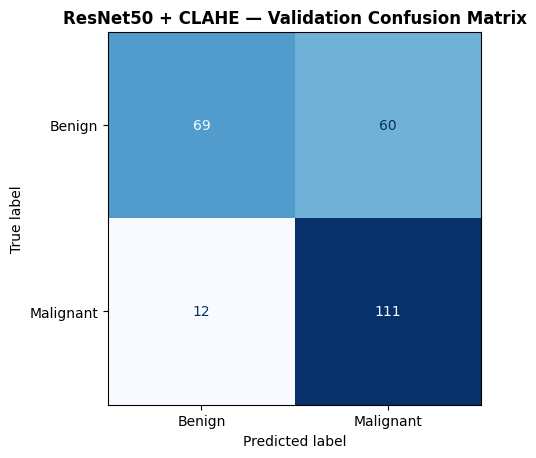

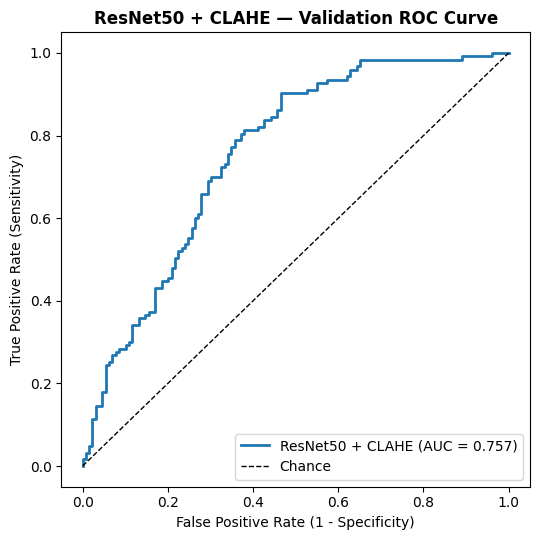

,model,threshold,accuracy,sensitivity,specificity,precision,auc
0,ResNet50,0.3814,0.7063,0.9187,0.5039,0.6384,0.7751
1,ResNet50 + CLAHE,0.3907,0.7143,0.9024,0.5349,0.6491,0.7574


In [40]:
# ResNet50 + CLAHE validation results

# Load saved best checkpoint
resnet_clahe_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_clahe_best.keras", compile=False
)

# Threshold selected ONLY on validation
resnet_clahe_threshold = find_best_threshold(resnet_clahe_model, resnet_clahe_val_ds)

# Evaluate ONLY on validation
resnet_clahe_results = evaluate_model(
    resnet_clahe_model,
    resnet_clahe_val_ds,
    name="ResNet50 + CLAHE",
    threshold=resnet_clahe_threshold,
    split_name="Validation",
)

# Validation confusion matrix
plot_confusion_matrix(
    resnet_clahe_results["cm"],
    "ResNet50 + CLAHE - Validation Confusion Matrix",
    save_path=f"{BASE}/cm_resnet50_clahe_validation.png",
)

# Validation ROC curve
plot_roc_curve(
    resnet_clahe_results,
    title="ResNet50 + CLAHE - Validation ROC Curve",
    save_path=f"{BASE}/roc_resnet50_clahe_validation.png",
)

# Compare ResNet50 vs ResNet50 + CLAHE on VALIDATION only
resnet_clahe_comparison = pd.DataFrame([resnet_results, resnet_clahe_results])[
    ["model", "threshold", "accuracy", "sensitivity", "specificity", "precision", "auc"]
]

display(resnet_clahe_comparison)

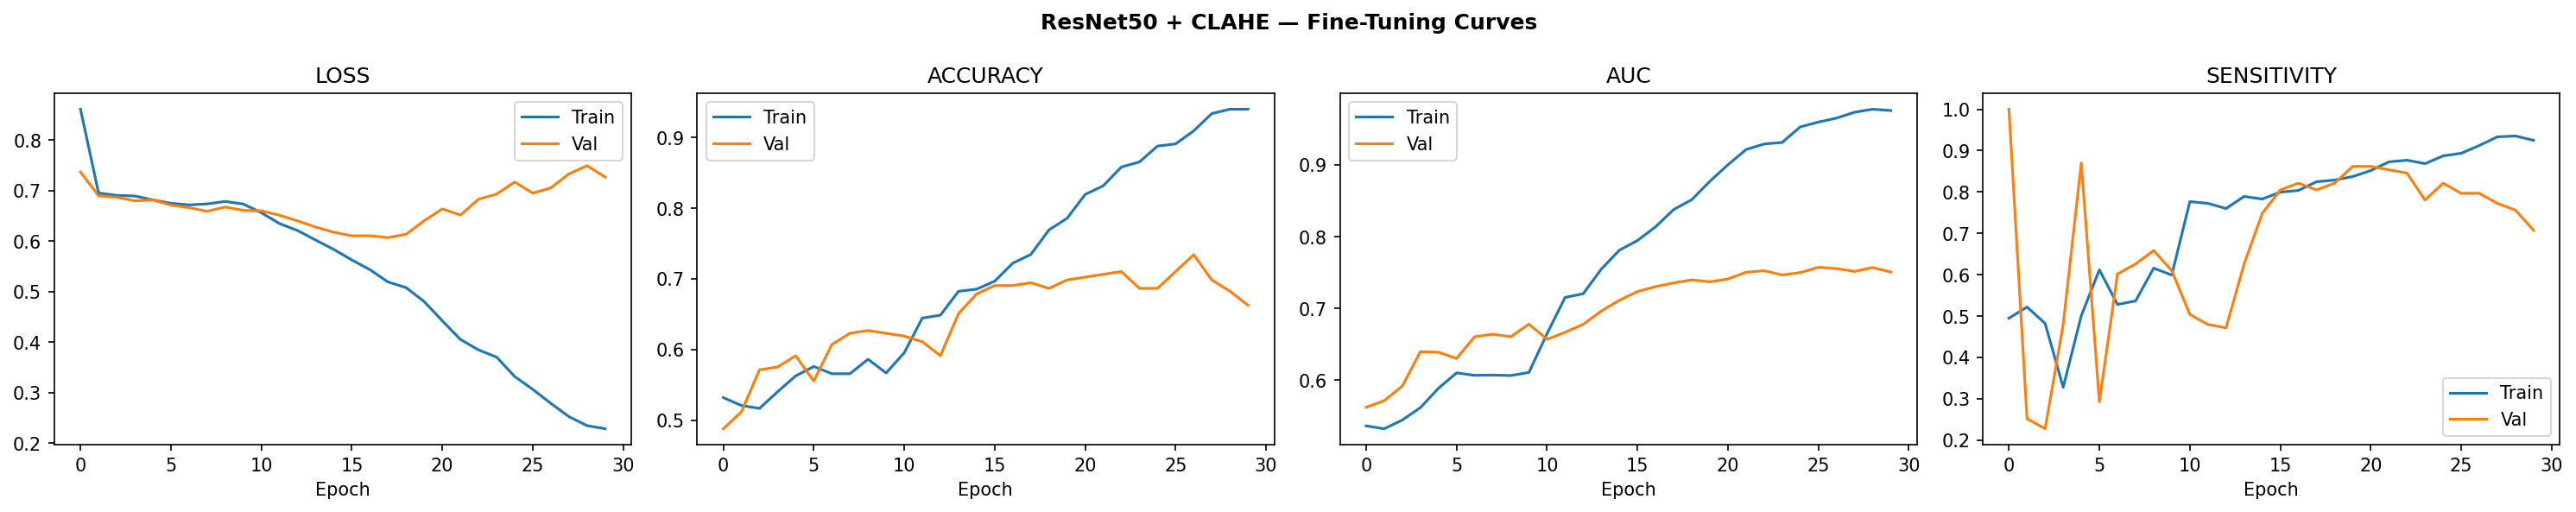

In [17]:
# Original training curves

from IPython.display import Image, display

display(Image(filename=f"{BASE}/curves_resnet50_clahe.png"))

## Section 24: Grad-CAM - ResNet50 + CLAHE

Grad-CAM is used to inspect regions contributing to predictions from ResNet50 + CLAHE. Images follow the same **crop → CLAHE → resize → ResNet50 preprocessing** pipeline used during model development.

Heatmaps are restricted to the breast region to reduce activation from black or padded background areas. These visualisations provide qualitative interpretability evidence rather than tumour segmentation.

Optimal threshold (Youden's J): 0.391  (val sensitivity=0.902, val specificity=0.535)
CLAHE validation threshold: 0.3907


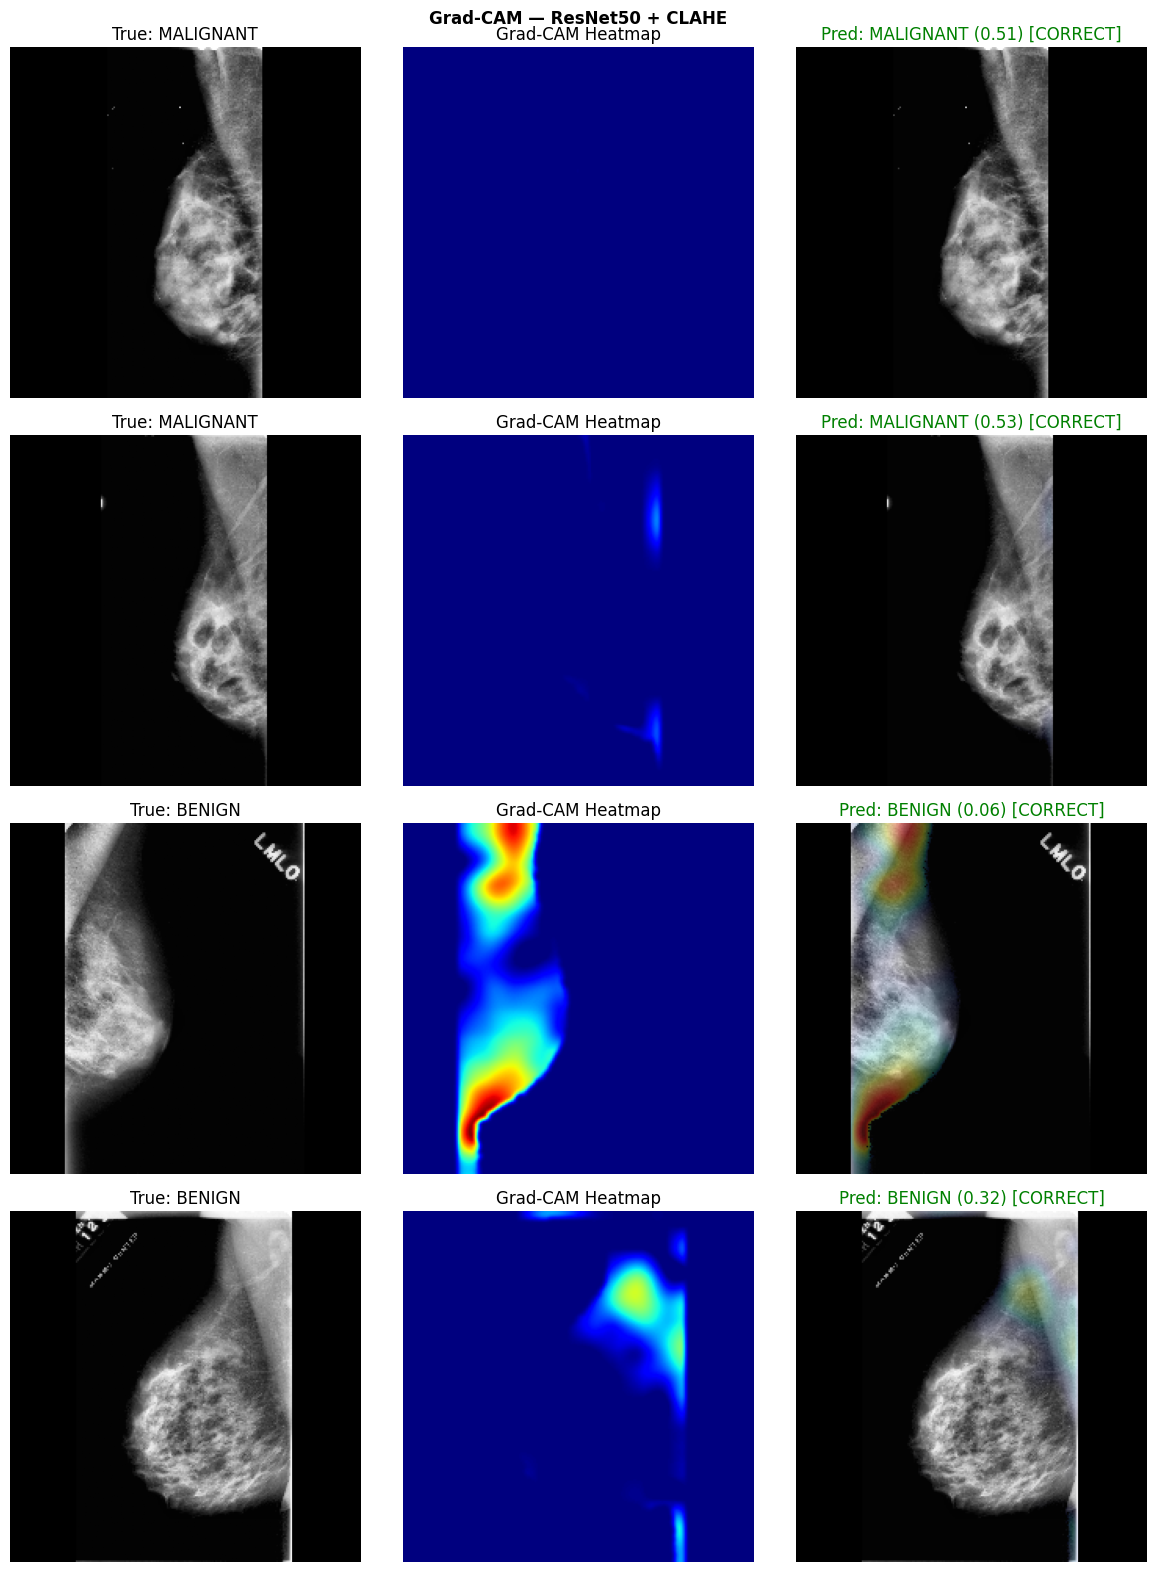

In [42]:
# ResNet50 + CLAHE Grad-CAM (no training needed)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# Model + validation-selected threshold
model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_clahe_best.keras", compile=False
)
threshold = find_best_threshold(model, resnet_clahe_val_ds, verbose=False)
print(f"CLAHE validation threshold: {threshold:.4f}")

# Build Grad-CAM model once
layer = model.get_layer("conv4_block6_out")
grad_model = tf.keras.Model(model.input, [layer.output, model.output])


def breast_mask(img):
    binary = (img.mean(axis=-1) > 0.03).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, 8)

    if n <= 1:
        return binary.astype(np.float32)

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = (labels == largest).astype(np.float32)
    return np.clip(cv2.GaussianBlur(mask, (7, 7), 0), 0, 1)


def prepare_image(path):
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    img = crop_to_content(img).numpy().astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.createCLAHE(2.0, (8, 8)).apply(gray)
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    resized = tf.image.resize_with_pad(
        tf.cast(rgb, tf.float32), IMG_SIZE_224, IMG_SIZE_224
    )

    display = resized.numpy() / 255.0
    x = preprocess_input(resized)[None, ...]

    return display, x


def gradcam(x, display):
    with tf.GradientTape() as tape:
        conv, pred = grad_model(x, training=False)
        p = pred[:, 0]
        loss = tf.where(p >= threshold, p, 1.0 - p)

    grads = tape.gradient(loss, conv)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heat = tf.squeeze(conv[0] @ weights[..., None])
    heat = tf.maximum(heat, 0)
    heat /= tf.reduce_max(heat) + 1e-8

    heat = cv2.resize(
        heat.numpy(), (IMG_SIZE_224, IMG_SIZE_224), interpolation=cv2.INTER_CUBIC
    )
    heat = np.clip(heat, 0, 1) * breast_mask(display)

    return heat, float(pred.numpy()[0, 0])


fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, (path, true) in enumerate(zip(GRADCAM_SAMPLES, GRADCAM_LABELS)):
    img, x = prepare_image(path)
    heat, prob = gradcam(x, img)

    pred = "MALIGNANT" if prob >= threshold else "BENIGN"
    correct = pred == true

    colour = plt.get_cmap("jet")(heat)[..., :3]
    alpha = heat[..., None] * 0.42
    overlay = img * (1 - alpha) + colour * alpha
    overlay[img.mean(axis=-1) <= 0.03] = img[img.mean(axis=-1) <= 0.03]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"True: {true}")

    axes[i, 1].imshow(heat, cmap="jet", vmin=0, vmax=1)
    axes[i, 1].set_title("Grad-CAM Heatmap")

    axes[i, 2].imshow(np.clip(overlay, 0, 1))
    axes[i, 2].set_title(
        f'Pred: {pred} ({prob:.2f}) [{"CORRECT" if correct else "WRONG"}]',
        color="green" if correct else "red",
    )

    for ax in axes[i]:
        ax.axis("off")

plt.suptitle("Grad-CAM - ResNet50 + CLAHE", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}/gradcam_resnet50_clahe_clean.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 25: Principal Model Comparison and Final Model Selection

The six principal models are compared using validation-set accuracy, sensitivity, specificity, precision and ROC-AUC. This comparison provides the evidence used for final-model selection.

Although plain ResNet50 achieved the highest validation sensitivity, **ResNet50 + CLAHE** retained sensitivity above 90% while improving accuracy, specificity and precision. It is therefore selected as the final balanced high-sensitivity configuration for held-out evaluation.

,model,threshold,accuracy,sensitivity,specificity,precision,auc
0,Baseline CNN (128px),0.5308,0.6667,0.6341,0.6977,0.6667,0.6938
1,Regularised Scaled CNN (128px),0.5567,0.6944,0.8618,0.5349,0.6386,0.7353
2,Regularised Scaled CNN (224px),0.4690,0.6627,0.8293,0.5039,0.6145,0.6856
3,VGG16,0.3172,0.7540,0.7642,0.7442,0.7402,0.8254
4,ResNet50,0.3814,0.7063,0.9187,0.5039,0.6384,0.7751
5,ResNet50 + CLAHE,0.3907,0.7143,0.9024,0.5349,0.6491,0.7574


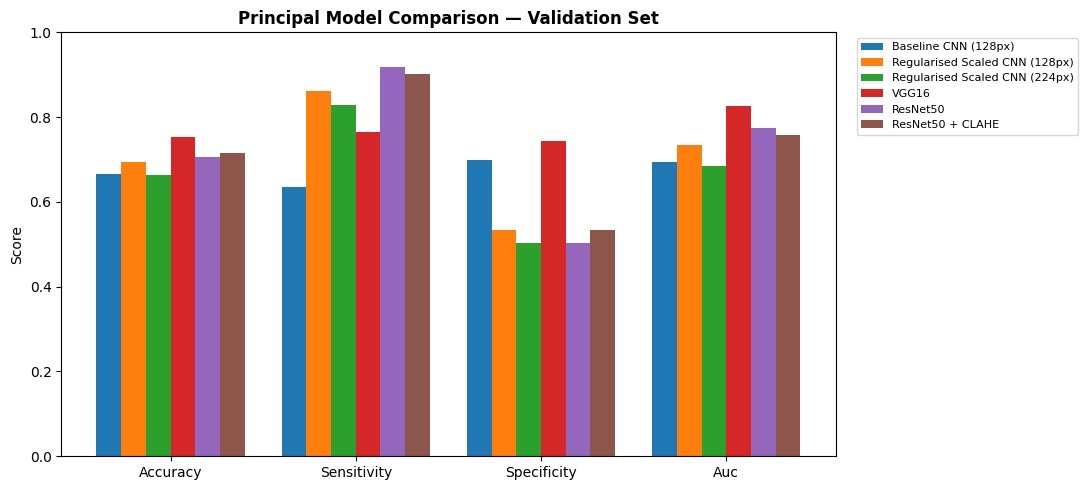

In [43]:
# Master model comparison on validation set

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = [
    baseline_principal_results,
    reg128_results,
    reg224_results,
    vgg_results,
    resnet_results,
    resnet_clahe_results,
]

master_comparison = pd.DataFrame(results)[
    ["model", "threshold", "accuracy", "sensitivity", "specificity", "precision", "auc"]
].round(4)

display(master_comparison)

# Metric comparison
metrics = ["accuracy", "sensitivity", "specificity", "auc"]
x = np.arange(len(metrics))
width = 0.8 / len(master_comparison)

fig, ax = plt.subplots(figsize=(11, 5))

for i, row in master_comparison.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row["model"])

ax.set_xticks(x + width * (len(master_comparison) - 1) / 2)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Principal Model Comparison - Validation Set", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(
    f"{BASE}/comparison_all_models_validation.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Section 26: Multi-Seed Robustness Analysis

ResNet50 and ResNet50 + CLAHE are evaluated across random seeds **42, 7 and 123** to examine sensitivity to stochastic training variation. Performance is summarised using mean ± standard deviation across the main evaluation metrics.

This is treated as a post-selection robustness analysis rather than a statistical significance test.

### Section 26.1: Three-Seed Evaluation

Existing checkpoints from each training seed are evaluated using thresholds derived independently from their corresponding validation predictions. Performance is then measured on the held-out test set for the robustness analysis.

In [15]:
# ResNet50 + CLAHE: 3-seed robustness check

import random, numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

train_clahe = prepare_resnet_dataset(train_ds_224_clahe)
val_clahe = prepare_resnet_dataset(val_ds_224_clahe)
test_clahe = prepare_resnet_dataset(test_ds_224_clahe)


def build_model():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(base.input, out)

    model.compile(
        Adam(1e-3),
        "binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )
    return model, base


def run_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    model, base = build_model()

    # Stage A - frozen base
    model.fit(
        train_clahe,
        validation_data=val_clahe,
        epochs=10,
        class_weight=class_weights,
        verbose=1,
    )

    # Stage B - fine-tune top 30%
    base.trainable = True
    for layer in base.layers[: int(len(base.layers) * 0.7)]:
        layer.trainable = False

    model.compile(
        Adam(1e-5),
        "binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ],
    )

    path = f"{MODELS_DIR}/resnet50_clahe_seed{seed}_best.keras"

    model.fit(
        train_clahe,
        validation_data=val_clahe,
        epochs=20,
        class_weight=class_weights,
        callbacks=[
            EarlyStopping(
                monitor="val_auc", patience=7, mode="max", restore_best_weights=True
            ),
            ModelCheckpoint(path, monitor="val_auc", mode="max", save_best_only=True),
        ],
        verbose=1,
    )

    best = tf.keras.models.load_model(path, compile=False)

    threshold = find_best_threshold(best, val_clahe, verbose=False)

    result = evaluate_model(
        best,
        test_clahe,
        name=f"ResNet50 + CLAHE (seed {seed})",
        threshold=threshold,
        split_name="Held-Out Test",
        verbose=False,
    )

    result["seed"] = seed
    tf.keras.backend.clear_session()

    return result


# Run 3 seeds
df = pd.DataFrame([run_seed(seed) for seed in [42, 7, 123]])

cols = [
    "seed",
    "threshold",
    "accuracy",
    "sensitivity",
    "specificity",
    "precision",
    "auc",
]

resnet_clahe_multiseed_df = df[cols]

display(resnet_clahe_multiseed_df.round(4))


# Mean ± SD
metrics = ["accuracy", "sensitivity", "specificity", "precision", "auc"]

summary = resnet_clahe_multiseed_df[metrics].agg(["mean", "std"])

for m in metrics:
    print(f"{m}: " f'{summary.loc["mean", m]:.4f} ± ' f'{summary.loc["std", m]:.4f}')


######################################################################
RESNET50 + CLAHE — SEED 42
######################################################################

Stage A: frozen ResNet50 base
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 736ms/step - accuracy: 0.5240 - auc: 0.5258 - loss: 0.8147 - precision: 0.5128 - sensitivity: 0.5449 - val_accuracy: 0.5357 - val_auc: 0.6485 - val_loss: 0.6889 - val_precision: 0.8000 - val_sensitivity: 0.0650
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.5271 - auc: 0.5461 - loss: 0.7017 - precision: 0.5161 - sensitivity: 0.5344 - val_accuracy: 0.5516 - val_auc: 0.6320 - val_loss: 0.6799 - val_precision: 0.6667 - val_sensitivity: 0.1626
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.5271 - auc: 0.5665 - loss: 0.6834 - precision: 0.5167 - sensitivity: 0.5157 - val_accuracy: 0.6151 - val_auc: 0.6820 - val_loss: 0.6574 - val_precision: 0.6140 - val_sensitivity: 0.5691
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 1

,seed,threshold,accuracy,sensitivity,specificity,precision,auc
0,42,0.4650,0.6094,0.8483,0.4491,0.5083,0.7378
1,7,0.4615,0.6150,0.7172,0.5463,0.5149,0.7177
2,123,0.3698,0.6565,0.8207,0.5463,0.5484,0.7333



Mean ± Std across 3 runs:
accuracy    : 0.6270 ± 0.0257
sensitivity : 0.7954 ± 0.0691
specificity : 0.5139 ± 0.0561
precision   : 0.5239 ± 0.0215
auc         : 0.7296 ± 0.0105


In [48]:
# Reload existing 3-seed results (no retraining)

import pandas as pd
import tensorflow as tf

rows = []

for seed in [42, 7, 123]:
    model = tf.keras.models.load_model(
        f"{MODELS_DIR}/resnet50_clahe_seed{seed}_best.keras", compile=False
    )

    threshold = find_best_threshold(model, resnet_clahe_val_ds, verbose=False)

    result = evaluate_model(
        model,
        resnet_clahe_test_ds,
        name=f"ResNet50 + CLAHE (seed {seed})",
        threshold=threshold,
        split_name="Held-Out Test",
        verbose=False,
    )

    result["seed"] = seed
    rows.append(result)

resnet_clahe_multiseed_df = pd.DataFrame(rows)[
    ["seed", "threshold", "accuracy", "sensitivity", "specificity", "precision", "auc"]
]

display(resnet_clahe_multiseed_df.round(4))

metrics = ["accuracy", "sensitivity", "specificity", "precision", "auc"]
summary = resnet_clahe_multiseed_df[metrics].agg(["mean", "std"])

print("\nMean ± Std across 3 runs:")
for m in metrics:
    print(f'{m}: {summary.loc["mean", m]:.4f} ± {summary.loc["std", m]:.4f}')

,seed,threshold,accuracy,sensitivity,specificity,precision,auc
0,42,0.4650,0.6094,0.8483,0.4491,0.5083,0.7378
1,7,0.4615,0.6150,0.7172,0.5463,0.5149,0.7177
2,123,0.3698,0.6565,0.8207,0.5463,0.5484,0.7333



Mean ± Std across 3 runs:
accuracy: 0.6270 ± 0.0257
sensitivity: 0.7954 ± 0.0691
specificity: 0.5139 ± 0.0561
precision: 0.5239 ± 0.0215
auc: 0.7296 ± 0.0105


### Section 26.2: Multi-Seed Comparison

Performance across the three seeds is summarised using mean ± standard deviation. ResNet50 + CLAHE shows slightly higher mean accuracy, specificity, precision and ROC-AUC, while plain ResNet50 retains slightly higher mean sensitivity.

The results provide evidence about training stability and are not interpreted as statistical significance.

In [56]:
# 3-seed results with progress output

import os
import pandas as pd
import tensorflow as tf


def evaluate_seeds(prefix, val_ds, test_ds):
    rows = []

    for i, seed in enumerate([42, 7, 123], 1):

        version = "final" if prefix == "resnet50" and seed == 42 else "best"

        print(f"\n[{i}/3] {prefix} - Seed {seed}")
        print(f"    Loading {version} checkpoint...")

        model = tf.keras.models.load_model(
            os.path.join(MODELS_DIR, f"{prefix}_seed{seed}_{version}.keras"),
            compile=False,
        )

        print("    Finding validation threshold...")

        threshold = find_best_threshold(model, val_ds, verbose=True)

        print(f"    Threshold = {threshold:.4f}")
        print("    Evaluating held-out test set...")

        result = evaluate_model(
            model,
            test_ds,
            name=f"{prefix} seed {seed}",
            threshold=threshold,
            split_name="Held-Out Test",
            verbose=True,
        )

        result["seed"] = seed
        rows.append(result)

        print(f"    ✓ Seed {seed} complete")

        del model
        tf.keras.backend.clear_session()

    return pd.DataFrame(rows)[
        [
            "seed",
            "threshold",
            "accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "auc",
        ]
    ]


print("\n===== RESNET50 =====")
resnet_multiseed_df = evaluate_seeds("resnet50", resnet_val_ds, resnet_test_ds)

print("\n===== RESNET50 + CLAHE =====")
resnet_clahe_multiseed_df = evaluate_seeds(
    "resnet50_clahe", resnet_clahe_val_ds, resnet_clahe_test_ds
)

print("\n===== FINAL RESULTS =====")

print("\nResNet50")
display(resnet_multiseed_df.round(4))

print("\nResNet50 + CLAHE")
display(resnet_clahe_multiseed_df.round(4))


===== RESNET50 =====

[1/3] resnet50 — Seed 42
    Loading final checkpoint...
    Finding validation threshold...
Optimal threshold (Youden's J): 0.504  (val sensitivity=0.724, val specificity=0.667)
    Threshold = 0.5042
    Evaluating held-out test set...

resnet50 seed 42 — Held-Out Test Results (threshold=0.504)
              precision    recall  f1-score   support

      Benign       0.75      0.59      0.66       216
   Malignant       0.54      0.71      0.61       145

    accuracy                           0.64       361
   macro avg       0.65      0.65      0.64       361
weighted avg       0.67      0.64      0.64       361

Accuracy    : 0.6399
Sensitivity : 0.7103  (missed 42 of 145 malignant cases)
Specificity : 0.5926
Precision   : 0.5393
AUC         : 0.7142
    ✓ Seed 42 complete

[2/3] resnet50 — Seed 7
    Loading best checkpoint...
    Finding validation threshold...
Optimal threshold (Youden's J): 0.177  (val sensitivity=0.935, val specificity=0.481)
    Thresh

,seed,threshold,accuracy,sensitivity,specificity,precision,auc
0,42,0.5042,0.6399,0.7103,0.5926,0.5393,0.7142
1,7,0.1766,0.5762,0.8759,0.3750,0.4847,0.7326
2,123,0.4235,0.6205,0.8621,0.4583,0.5165,0.7123



ResNet50 + CLAHE


,seed,threshold,accuracy,sensitivity,specificity,precision,auc
0,42,0.4650,0.6094,0.8483,0.4491,0.5083,0.7378
1,7,0.4615,0.6150,0.7172,0.5463,0.5149,0.7177
2,123,0.3698,0.6565,0.8207,0.5463,0.5484,0.7333


In [57]:
# Multi-seed robustness summary

metrics = ["accuracy", "sensitivity", "specificity", "precision", "auc"]

comparison = pd.DataFrame(
    {
        "ResNet50 Mean": resnet_multiseed_df[metrics].mean(),
        "ResNet50 Std": resnet_multiseed_df[metrics].std(),
        "ResNet50 + CLAHE Mean": resnet_clahe_multiseed_df[metrics].mean(),
        "ResNet50 + CLAHE Std": resnet_clahe_multiseed_df[metrics].std(),
    }
)

display(comparison.round(4))

resnet_auc = resnet_multiseed_df["auc"].mean()
clahe_auc = resnet_clahe_multiseed_df["auc"].mean()

print(f"Mean AUC difference (CLAHE - plain): " f"{clahe_auc - resnet_auc:+.4f}")

print(
    "\nThree-seed results are reported as a robustness check, "
    "not as a formal statistical significance test."
)

,ResNet50 Mean,ResNet50 Std,ResNet50 + CLAHE Mean,ResNet50 + CLAHE Std
accuracy,0.6122,0.0327,0.6270,0.0257
sensitivity,0.8161,0.0919,0.7954,0.0691
specificity,0.4753,0.1098,0.5139,0.0561
precision,0.5135,0.0274,0.5239,0.0215
auc,0.7197,0.0112,0.7296,0.0105


Mean AUC difference (CLAHE - plain): +0.0099

Three-seed results are reported as a robustness check, not as a formal statistical significance test.


## Section 27: Final Evaluation and Results

This section consolidates the principal validation comparison, formal held-out evaluation of the selected model, robustness results and final qualitative interpretability analysis.

### Section 27.1: Final Results

The final results distinguish between **validation-based model comparison**, **formal held-out test evaluation**, and **multi-seed robustness analysis**. This preserves the separation between evidence used for model selection and subsequent evaluation of the selected model.

ResNet50 + CLAHE is the selected final model and is evaluated using its frozen validation-derived threshold.

In [59]:
# Rebuild principal results table

principal_results = pd.DataFrame(
    [
        {
            "Model": r["model"],
            "Threshold": r["threshold"],
            "Accuracy": r["accuracy"],
            "Sensitivity": r["sensitivity"],
            "Specificity": r["specificity"],
            "Precision": r["precision"],
            "AUC": r["auc"],
        }
        for r in [
            baseline_principal_results,
            reg128_results,
            reg224_results,
            vgg_results,
            resnet_results,
            resnet_clahe_results,
        ]
    ]
)

display(principal_results.round(4))

,Model,Threshold,Accuracy,Sensitivity,Specificity,Precision,AUC
0,Baseline CNN (128px),0.5308,0.6667,0.6341,0.6977,0.6667,0.6938
1,Regularised Scaled CNN (128px),0.5567,0.6944,0.8618,0.5349,0.6386,0.7353
2,Regularised Scaled CNN (224px),0.4690,0.6627,0.8293,0.5039,0.6145,0.6856
3,VGG16,0.3172,0.7540,0.7642,0.7442,0.7402,0.8254
4,ResNet50,0.3814,0.7063,0.9187,0.5039,0.6384,0.7751
5,ResNet50 + CLAHE,0.3907,0.7143,0.9024,0.5349,0.6491,0.7574


### Section 27.2: Final Selected Model - Held-Out Test Evaluation

Following validation-based model selection, **ResNet50 + CLAHE** is evaluated on the held-out test set using the frozen validation-derived threshold of **0.3907**.

This represents the formal held-out performance of the selected final model.

In [80]:
# Final model: held-out test evaluation

final_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_clahe_best.keras", compile=False
)

# Freeze threshold selected from VALIDATION
final_threshold = resnet_clahe_threshold

final_test_results = evaluate_model(
    final_model,
    resnet_clahe_test_ds,
    name="ResNet50 + CLAHE",
    threshold=final_threshold,
    split_name="Held-Out Test",
)

final_test_table = pd.DataFrame(
    [
        {
            "Model": final_test_results["model"],
            "Threshold": final_test_results["threshold"],
            "Accuracy": final_test_results["accuracy"],
            "Sensitivity": final_test_results["sensitivity"],
            "Specificity": final_test_results["specificity"],
            "Precision": final_test_results["precision"],
            "AUC": final_test_results["auc"],
        }
    ]
).round(4)

display(final_test_table)


ResNet50 + CLAHE — Held-Out Test Results (threshold=0.391)
              precision    recall  f1-score   support

      Benign       0.84      0.50      0.63       216
   Malignant       0.54      0.86      0.66       145

    accuracy                           0.65       361
   macro avg       0.69      0.68      0.65       361
weighted avg       0.72      0.65      0.64       361

Accuracy    : 0.6482
Sensitivity : 0.8621  (missed 20 of 145 malignant cases)
Specificity : 0.5046
Precision   : 0.5388
AUC         : 0.7457


,Model,Threshold,Accuracy,Sensitivity,Specificity,Precision,AUC
0,ResNet50 + CLAHE,0.3907,0.6482,0.8621,0.5046,0.5388,0.7457


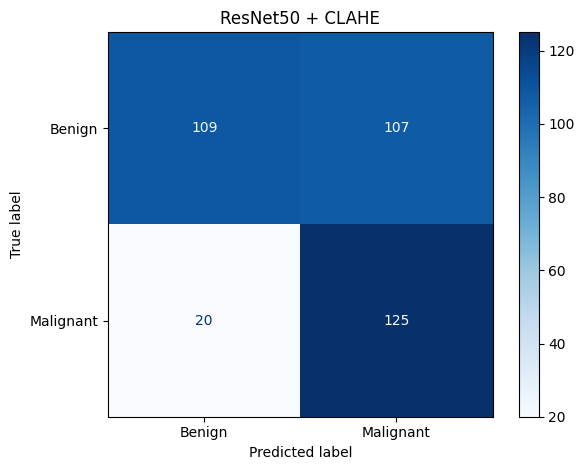

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Final held-out test confusion matrix
# [[TN, FP],
#  [FN, TP]]
cm = np.array([[109, 107], [20, 125]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("ResNet50 + CLAHE")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

### Section 27.3: Validation ROC Curves and Confusion Matrices

ROC curves and confusion matrices summarise the validation behaviour of the six principal models. These visualisations present the validation evidence used during model comparison and selection.

All current corrected principal models loaded.


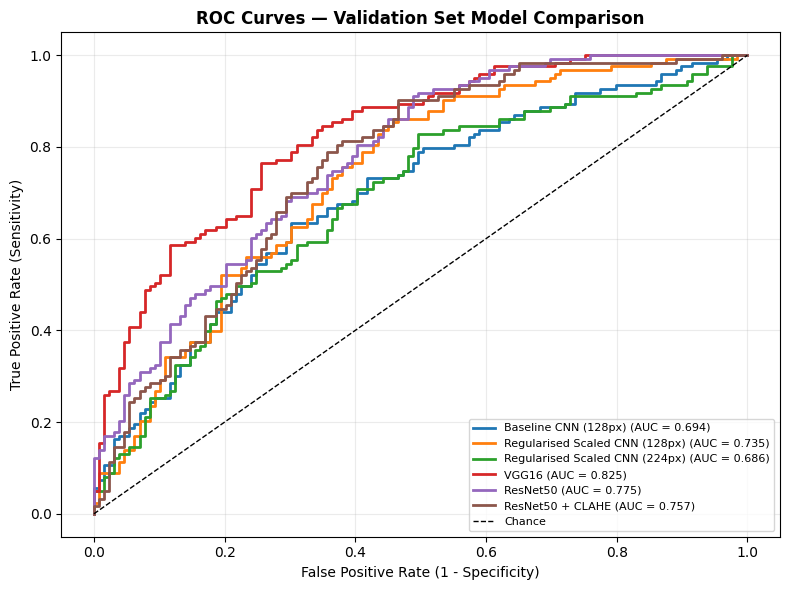

In [61]:
# ROC curves for all principal models

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load models
model_files = {
    "Baseline CNN (128px)": "baseline_cnn_best.keras",
    "Regularised Scaled CNN (128px)": "regularised_scaled_cnn_128_best.keras",
    "Regularised Scaled CNN (224px)": "regularised_scaled_cnn_224_best.keras",
    "VGG16": "vgg16_best.keras",
    "ResNet50": "resnet50_best.keras",
    "ResNet50 + CLAHE": "resnet50_clahe_best.keras",
}

models = {
    name: tf.keras.models.load_model(f"{MODELS_DIR}/{file}", compile=False)
    for name, file in model_files.items()
}

# Transfer-learning validation datasets
if "vgg_val_ds" not in globals():
    vgg_val_ds = prepare_vgg_dataset(val_ds_224)

if "resnet_val_ds" not in globals():
    resnet_val_ds = prepare_resnet_dataset(val_ds_224)

if "resnet_clahe_val_ds" not in globals():
    resnet_clahe_val_ds = prepare_resnet_dataset(val_ds_224_clahe)

datasets = {
    "Baseline CNN (128px)": val_ds_128,
    "Regularised Scaled CNN (128px)": val_ds_128,
    "Regularised Scaled CNN (224px)": val_ds_224,
    "VGG16": vgg_val_ds,
    "ResNet50": resnet_val_ds,
    "ResNet50 + CLAHE": resnet_clahe_val_ds,
}

# ROC curves
plt.figure(figsize=(8, 6))

for name, model in models.items():
    ds = datasets[name]

    y_prob = model.predict(ds, verbose=0).ravel()
    y_true = np.concatenate([y.numpy().ravel() for _, y in ds]).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    score = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {score:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves - Validation Set Model Comparison", fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(f"{BASE}/roc_all_models_validation.png", dpi=300, bbox_inches="tight")
plt.show()

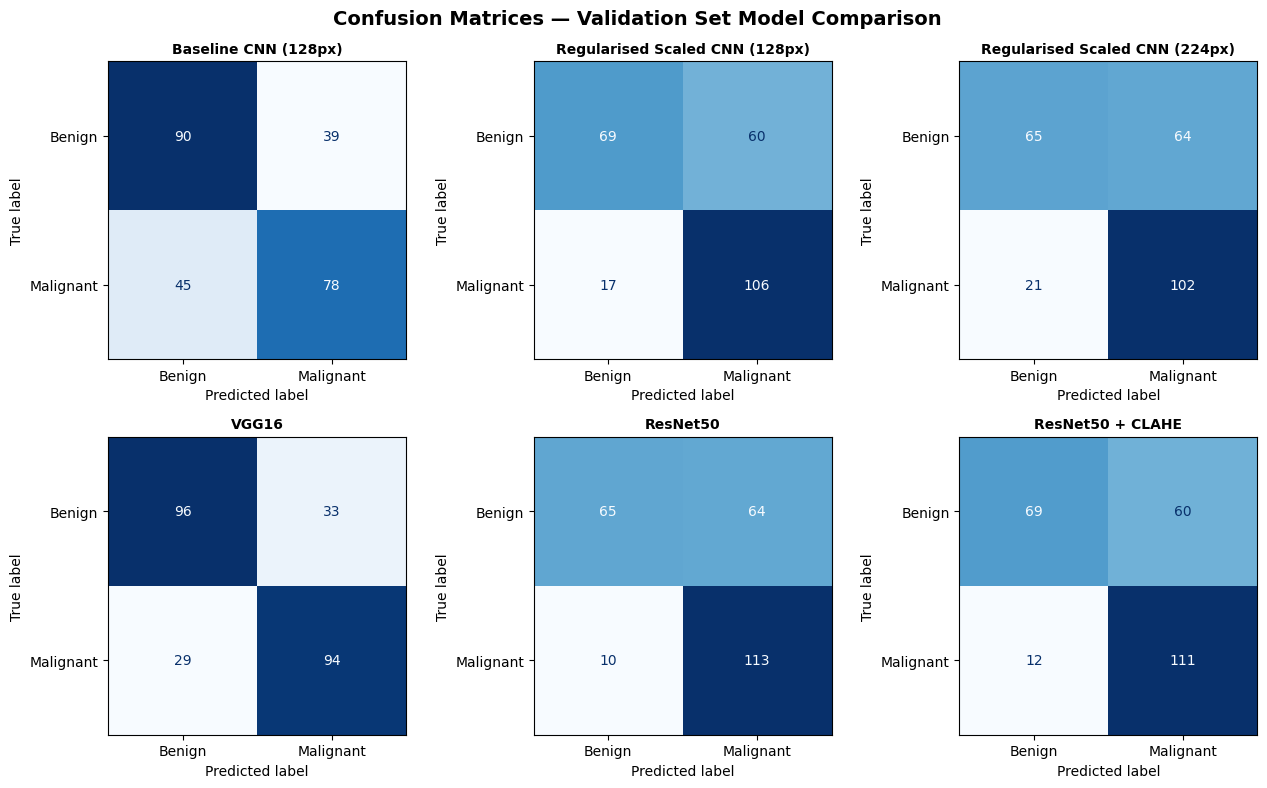

In [62]:
# Confusion matrices for principal models (validation set)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Current validation results

current_results = [
    baseline_principal_results,
    reg128_results,
    reg224_results,
    vgg_results,
    resnet_results,
    resnet_clahe_results,
]


# Create figure

fig, axes = plt.subplots(2, 3, figsize=(13, 8))


# Plot each confusion matrix

for ax, result in zip(axes.flat, current_results):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["cm"], display_labels=["Benign", "Malignant"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

    ax.set_title(result["model"], fontweight="bold", fontsize=10)


# Format

plt.suptitle(
    "Confusion Matrices - Validation Set Model Comparison",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()


# Save

plt.savefig(
    f"{BASE}/confusion_matrices_all_models_validation.png", dpi=300, bbox_inches="tight"
)

plt.show()

### Section 27.4: Multi-Seed Robustness Summary

The three-seed results for ResNet50 and ResNet50 + CLAHE are summarised as mean ± standard deviation across the main evaluation metrics. This provides a compact view of performance stability across repeated training runs.

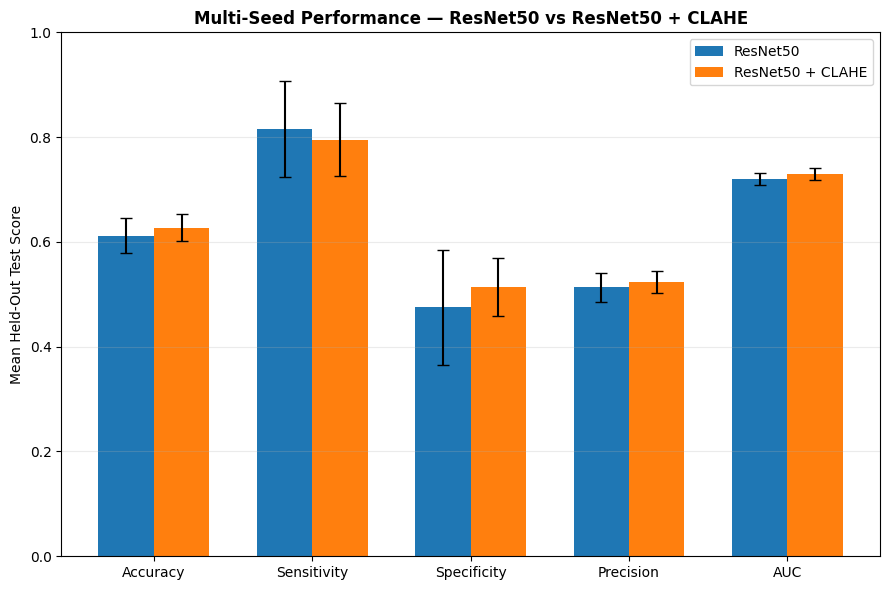

In [63]:
# Figure 5.3: multi-seed mean +/- SD comparison

import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Sensitivity", "Specificity", "Precision", "AUC"]

metric_cols = ["accuracy", "sensitivity", "specificity", "precision", "auc"]

# Calculate directly from regenerated results
resnet_mean = resnet_multiseed_df[metric_cols].mean().values
resnet_std = resnet_multiseed_df[metric_cols].std().values

clahe_mean = resnet_clahe_multiseed_df[metric_cols].mean().values
clahe_std = resnet_clahe_multiseed_df[metric_cols].std().values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(x - width / 2, resnet_mean, width, yerr=resnet_std, capsize=4, label="ResNet50")

plt.bar(
    x + width / 2,
    clahe_mean,
    width,
    yerr=clahe_std,
    capsize=4,
    label="ResNet50 + CLAHE",
)

plt.xticks(x, metrics)
plt.ylabel("Mean Held-Out Test Score")
plt.ylim(0, 1)

plt.title("Multi-Seed Performance - ResNet50 vs ResNet50 + CLAHE", fontweight="bold")

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    f"{BASE}/multiseed_resnet_vs_clahe_corrected.png", dpi=300, bbox_inches="tight"
)

plt.show()

### Section 27.5: Grad-CAM Case Analysis - Final Selected Model

Grad-CAM is used to qualitatively examine the selected **ResNet50 + CLAHE** model using one true positive, true negative, false negative and false positive case from the held-out test set.

The same preprocessing and Grad-CAM configuration used for the final model are reproduced. These examples illustrate model attention for correct and incorrect predictions and are interpreted as post-hoc explanations rather than lesion segmentation.

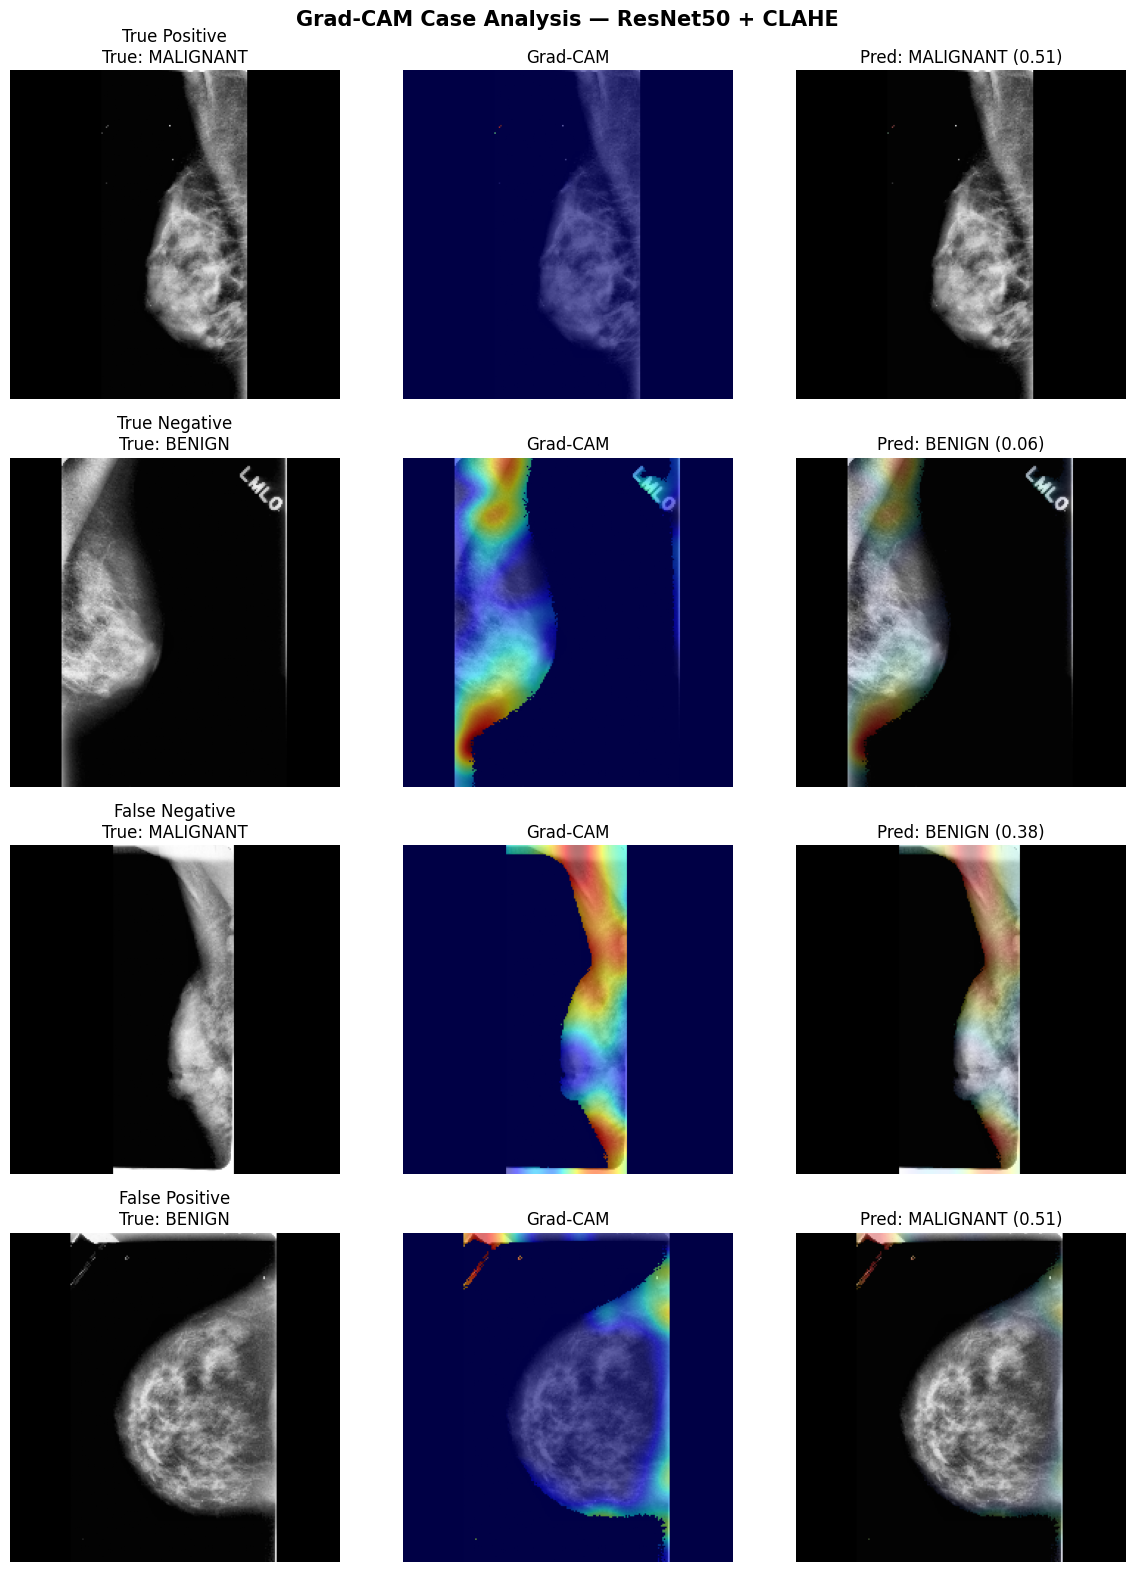

Threshold: 0.3907
Saved: /content/drive/MyDrive/cbis_ddsm/gradcam_case_analysis_corrected.png


In [64]:
# Figure 5.4: Grad-CAM case analysis (TP, TN, FN, FP)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load model + validation-selected threshold
model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_clahe_best.keras", compile=False
)

threshold = find_best_threshold(model, resnet_clahe_val_ds, verbose=False)

# Grad-CAM model
layer = model.get_layer("conv4_block6_out")
grad_model = tf.keras.Model(model.input, [layer.output, model.output])


def gradcam(path):
    # Same CLAHE preprocessing as model
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    img = crop_to_content(img).numpy().astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.createCLAHE(2.0, (8, 8)).apply(gray)
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    resized = tf.image.resize_with_pad(
        tf.cast(rgb, tf.float32), IMG_SIZE_224, IMG_SIZE_224
    )

    display = resized.numpy() / 255.0
    x = preprocess_input(resized)[None, ...]

    # Explain predicted class
    with tf.GradientTape() as tape:
        conv, pred = grad_model(x, training=False)
        p = pred[:, 0]
        loss = tf.where(p >= threshold, p, 1.0 - p)

    grads = tape.gradient(loss, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    heat = tf.reduce_sum(conv[0] * weights[0], axis=-1)
    heat = tf.maximum(heat, 0).numpy()

    heat = cv2.resize(heat, (IMG_SIZE_224, IMG_SIZE_224), interpolation=cv2.INTER_CUBIC)
    heat = np.clip(heat, 0, None)

    # Remove attribution outside breast
    heat *= display.mean(axis=-1) > 0.03

    if heat.max() > 0:
        heat /= heat.max()

    prob = float(pred.numpy()[0, 0])
    pred_label = "MALIGNANT" if prob >= threshold else "BENIGN"

    return display, heat, pred_label, prob


# Find first TP, TN, FN and FP deterministically
cases = {
    "True Positive": None,
    "True Negative": None,
    "False Negative": None,
    "False Positive": None,
}

for path, true in zip(X_test, y_test):
    img, heat, pred, prob = gradcam(path)
    true = "MALIGNANT" if int(true) == 1 else "BENIGN"

    if true == "MALIGNANT" and pred == "MALIGNANT":
        key = "True Positive"
    elif true == "BENIGN" and pred == "BENIGN":
        key = "True Negative"
    elif true == "MALIGNANT":
        key = "False Negative"
    else:
        key = "False Positive"

    if cases[key] is None:
        cases[key] = (img, heat, true, pred, prob)

    if all(v is not None for v in cases.values()):
        break


# Plot
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, (case_type, case) in enumerate(cases.items()):
    img, heat, true, pred, prob = case

    colour = plt.get_cmap("jet")(heat)[..., :3]
    alpha = heat[..., None] * 0.35
    overlay = np.clip(img * (1 - alpha) + colour * alpha, 0, 1)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{case_type}\nTrue: {true}")

    axes[i, 1].imshow(img)
    axes[i, 1].imshow(heat, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    axes[i, 1].set_title("Grad-CAM")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f"Pred: {pred} ({prob:.2f})")

    for ax in axes[i]:
        ax.axis("off")

plt.suptitle(
    "Grad-CAM Case Analysis - ResNet50 + CLAHE", fontsize=15, fontweight="bold"
)
plt.tight_layout()

plt.savefig(f"{BASE}/gradcam_case_analysis_corrected.png", dpi=300, bbox_inches="tight")

plt.show()

print(f"Threshold: {threshold:.4f}")
print(f"Saved: {BASE}/gradcam_case_analysis_corrected.png")

## Section 28: McNemar Significance Test

An exact McNemar test provides a paired comparison between ResNet50 and ResNet50 + CLAHE on the same held-out test cases. Each model uses its independently derived validation threshold.

The resulting **p = 0.1112** indicates no statistically significant evidence of a difference in paired classification correctness at α = 0.05.

In [29]:
# McNemar test: ResNet50 vs ResNet50 + CLAHE

import numpy as np
import tensorflow as tf
from scipy.stats import binomtest

# Rebuild datasets if needed

if "resnet_val_ds" not in globals():
    resnet_val_ds = prepare_resnet_dataset(val_ds_224)

if "resnet_test_ds" not in globals():
    resnet_test_ds = prepare_resnet_dataset(test_ds_224)

if "resnet_clahe_val_ds" not in globals():
    resnet_clahe_val_ds = prepare_resnet_dataset(val_ds_224_clahe)

if "resnet_clahe_test_ds" not in globals():
    resnet_clahe_test_ds = prepare_resnet_dataset(test_ds_224_clahe)

# Load principal models

resnet_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_best.keras", compile=False
)

resnet_clahe_model = tf.keras.models.load_model(
    f"{MODELS_DIR}/resnet50_clahe_best.keras", compile=False
)

# Select thresholds using validation set only

RESNET_THRESHOLD = find_best_threshold(resnet_model, resnet_val_ds, verbose=False)

CLAHE_THRESHOLD = find_best_threshold(
    resnet_clahe_model, resnet_clahe_val_ds, verbose=False
)

print(f"ResNet50 threshold: {RESNET_THRESHOLD:.4f}")
print(f"CLAHE threshold:    {CLAHE_THRESHOLD:.4f}")

# Test labels and predictions


def get_labels(ds):
    return np.concatenate([y.numpy().ravel() for _, y in ds]).astype(int)


y_plain = get_labels(resnet_test_ds)
y_clahe = get_labels(resnet_clahe_test_ds)

assert len(y_plain) == 361
assert len(y_clahe) == 361
assert np.array_equal(y_plain, y_clahe)

y_true = y_plain

p_resnet = resnet_model.predict(resnet_test_ds, verbose=0).ravel()

p_clahe = resnet_clahe_model.predict(resnet_clahe_test_ds, verbose=0).ravel()

pred_resnet = (p_resnet >= RESNET_THRESHOLD).astype(int)
pred_clahe = (p_clahe >= CLAHE_THRESHOLD).astype(int)

# McNemar paired counts

r_correct = pred_resnet == y_true
c_correct = pred_clahe == y_true

both_correct = int(np.sum(r_correct & c_correct))
resnet_only = int(np.sum(r_correct & ~c_correct))
clahe_only = int(np.sum(~r_correct & c_correct))
both_wrong = int(np.sum(~r_correct & ~c_correct))

discordant = resnet_only + clahe_only

p_value = (
    binomtest(
        min(resnet_only, clahe_only), discordant, p=0.5, alternative="two-sided"
    ).pvalue
    if discordant > 0
    else 1.0
)

# Results

print("\nMcNemar Test - Held-Out Test Set")
print("=" * 45)
print(f"Both correct          : {both_correct}")
print(f"ResNet50 only correct : {resnet_only}")
print(f"CLAHE only correct    : {clahe_only}")
print(f"Both wrong            : {both_wrong}")
print(f"Discordant cases      : {discordant}")
print(f"Exact p-value         : {p_value:.6f}")

if p_value < 0.05:
    print("Result: statistically significant difference (p < 0.05).")
else:
    print("Result: no statistically significant difference (p >= 0.05).")

Loading corrected principal models...


ResNet50 validation-selected threshold: 0.3814
ResNet50 + CLAHE validation-selected threshold: 0.3907

Plain test cases: 361
CLAHE test cases: 361

ResNet50 test accuracy from predictions: 0.6122
ResNet50 + CLAHE test accuracy from predictions: 0.6482

McNemar Test: ResNet50 vs ResNet50 + CLAHE
Both correct            : 199
ResNet50 only correct   : 22
CLAHE only correct      : 35
Both wrong              : 105
Discordant cases        : 57

Exact McNemar p-value   : 0.111161
Result: no statistically significant difference between the paired model predictions (p >= 0.05).


## Section 29: Quantitative Grad-CAM Lesion-Mask Evaluation

Grad-CAM activation from the final ResNet50 + CLAHE model is compared with the malignant lesion masks provided by CBIS-DDSM. ROI geometry and mask alignment are first verified before localisation is evaluated across the malignant held-out cases.

This analysis examines whether model attention spatially corresponds with annotated abnormalities; Grad-CAM is not treated as a segmentation method.

In [16]:
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 15.1 MB/s eta 0:00:00


dicom_info rows: 10237
ROI mask metadata rows: 3247
ROI cases with real extracted files: 3247
Selected lesion rows: 4

Resolved ROI 1:
/content/drive/MyDrive/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.30820586311062570442302321942433426184/1-083.jpg

Resolved ROI 2:
/content/drive/MyDrive/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.381440141511137044327302306604206077287/1-084.jpg

Resolved ROI 3:
/content/drive/MyDrive/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.212143028513012144941507232513982203672/2-085.jpg

Resolved ROI 4:
/content/drive/MyDrive/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.15403043813402510742192372832381918984/2-086.jpg


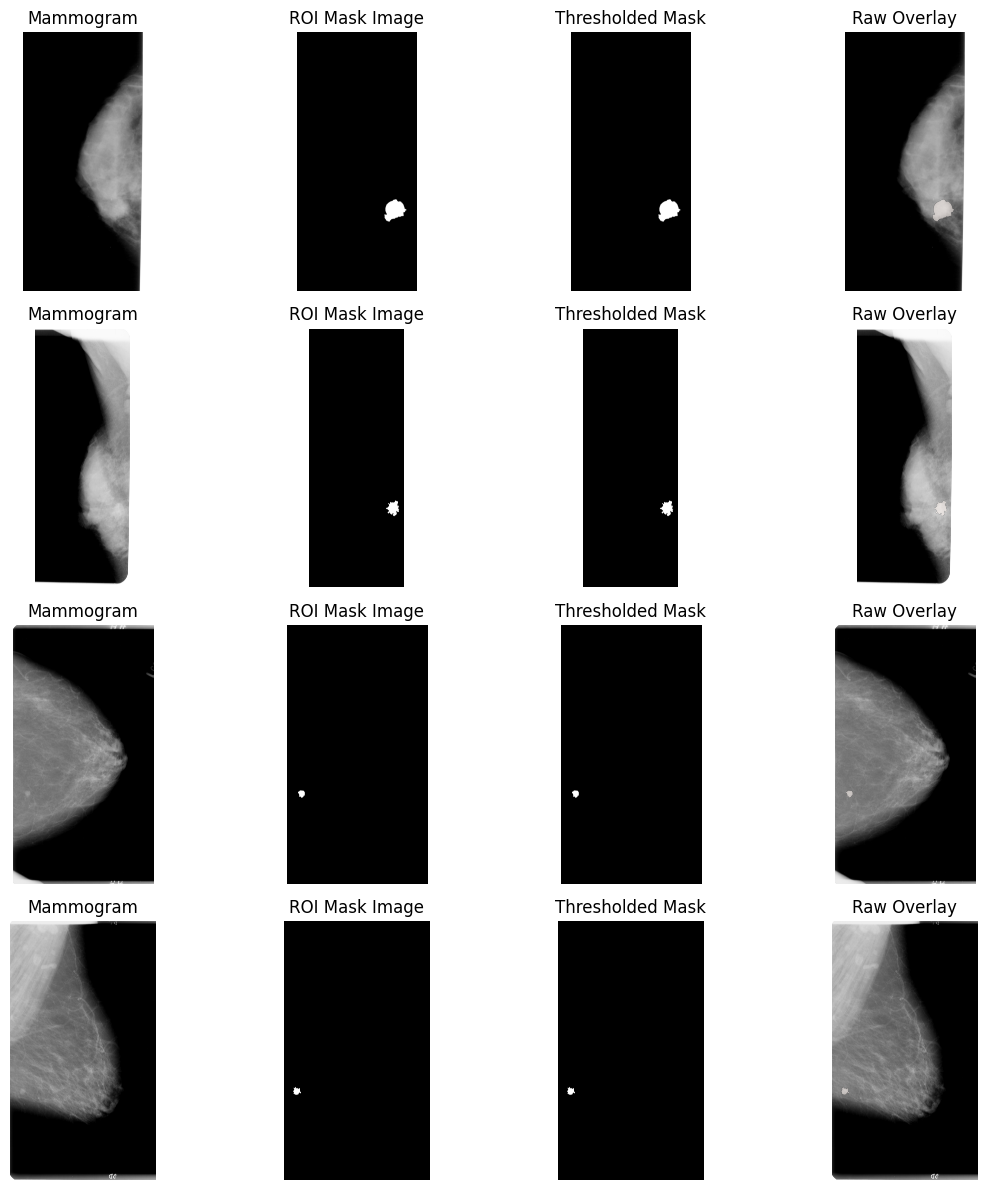

In [21]:
# Lesion mask sanity check

import os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_BASE = "/content/drive/MyDrive/cbis_ddsm"
MASK_COL = "ROI mask file path"

# DICOM metadata + real extracted paths
dicom_info = pd.read_csv(f"{DATA_BASE}/csv/dicom_info.csv")
dicom_info["real_path"] = (
    DATA_BASE
    + "/"
    + dicom_info["image_path"].astype(str).str.replace("CBIS-DDSM/", "", regex=False)
)

roi_info = dicom_info[dicom_info["SeriesDescription"] == "ROI mask images"]

roi_lookup = {}
for _, r in roi_info.iterrows():
    path = r["real_path"]
    if os.path.exists(path):
        roi_lookup.setdefault(str(r["PatientID"]).strip(), []).append(path)


def resolve_roi_image(csv_path):
    case_id = str(csv_path).replace("\\", "/").split("/")[0]
    for path in roi_lookup.get(case_id, []):
        if cv2.imread(path, cv2.IMREAD_GRAYSCALE) is not None:
            return path
    raise FileNotFoundError(f"No readable ROI for {case_id}")


sample = (
    test_lesion_csv[(test_lesion_csv["label"] == 1) & test_lesion_csv[MASK_COL].notna()]
    .drop_duplicates(["full_path", MASK_COL])
    .head(4)
)

fig, axes = plt.subplots(len(sample), 4, figsize=(12, 3 * len(sample)))
if len(sample) == 1:
    axes = axes[None, :]

for i, (_, row) in enumerate(sample.iterrows()):
    mamm = cv2.imread(row["full_path"], cv2.IMREAD_GRAYSCALE)
    roi = cv2.imread(resolve_roi_image(row[MASK_COL]), cv2.IMREAD_GRAYSCALE)

    _, mask = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if (mask > 0).mean() > 0.5:
        mask = 255 - mask

    overlay_mask = cv2.resize(
        mask, (mamm.shape[1], mamm.shape[0]), interpolation=cv2.INTER_NEAREST
    )

    axes[i, 0].imshow(mamm, cmap="gray")
    axes[i, 0].set_title("Mammogram")

    axes[i, 1].imshow(roi, cmap="gray")
    axes[i, 1].set_title("ROI Mask Image")

    axes[i, 2].imshow(mask, cmap="gray")
    axes[i, 2].set_title("Thresholded Mask")

    axes[i, 3].imshow(mamm, cmap="gray")
    axes[i, 3].imshow(
        np.ma.masked_where(overlay_mask == 0, overlay_mask), cmap="Reds", alpha=0.5
    )
    axes[i, 3].set_title("Raw Overlay")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(
    f"{BASE}/lesion_mask_sanity_check_corrected.png", dpi=200, bbox_inches="tight"
)
plt.show()

### Section 29.1: Quantitative Grad-CAM Setup

The final ResNet50 + CLAHE model and Grad-CAM utilities are prepared for lesion-level analysis. These functions reproduce the final model preprocessing and map Grad-CAM activation and lesion annotations into the same 224×224 coordinate system.

Case index: 0
Full path: /content/drive/MyDrive/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.334704328611391643805508991083300190349/1-108.jpg
Mask pixels: 114
Mask area fraction: 0.0022720026317983866
Malignancy score: 0.9514608383178711
Grad-CAM peak: (np.int64(135), np.int64(72))
Peak inside mask: False


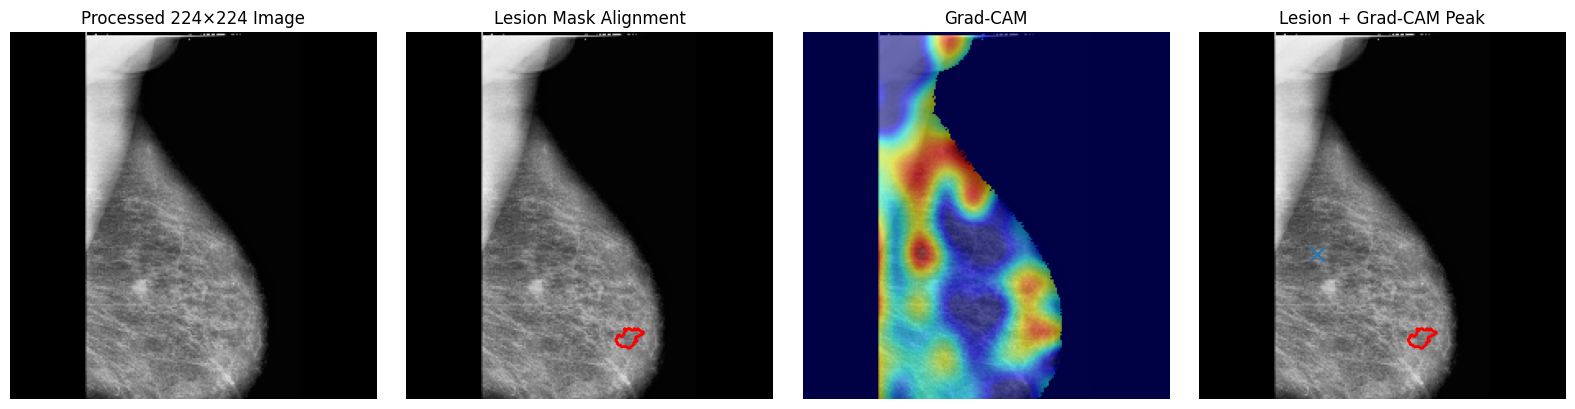

In [27]:
# ROI/crop geometry diagnostic

import cv2
import matplotlib.pyplot as plt

row = test_lesion_csv[test_lesion_csv["label"] == 1].iloc[0]

case_id = str(row["ROI mask file path"]).replace("\\", "/").split("/")[0]

case_meta = dicom_info[dicom_info["PatientID"].astype(str).str.strip() == case_id]


def get_case_image(series):
    rows = case_meta[case_meta["SeriesDescription"] == series]
    if rows.empty:
        return None, None
    path = rows.iloc[0]["real_path"]
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE), path


full_img = cv2.imread(row["full_path"], cv2.IMREAD_GRAYSCALE)
crop_img, crop_path = get_case_image("cropped images")
mask_img, mask_path = get_case_image("ROI mask images")

print("CASE:", case_id)
print("Full:", full_img.shape)
print("Crop:", None if crop_img is None else crop_img.shape)
print("Mask:", None if mask_img is None else mask_img.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(
    axes,
    [full_img, crop_img, mask_img],
    ["Full Mammogram", "Cropped Lesion", "ROI Mask"],
):
    if img is not None:
        ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Section 29.2: ROI and Crop Geometry Verification

The full mammogram, cropped lesion image and ROI mask are inspected to verify the relationship between the original CBIS-DDSM annotations and the preprocessing geometry used by the classification pipeline.

In [29]:
# Quantitative Grad-CAM lesion localisation

rows = []

malignant_indices = np.where(y == 1)[0]

for n, i in enumerate(malignant_indices, 1):

    mask = union_malignant_mask_224(str(X_test[i]))

    heat, prob = cam_exact(X[i])

    # Location of maximum Grad-CAM activation
    py, px = np.unravel_index(np.argmax(heat), heat.shape)

    peak_inside = bool(mask[py, px])

    # Fraction of total Grad-CAM activation inside lesion
    total_heat = heat.sum()
    lesion_heat = heat[mask].sum()

    heat_fraction = lesion_heat / total_heat if total_heat > 0 else 0.0

    # Fraction of image occupied by lesion
    area_fraction = mask.mean()

    # Attention enrichment relative to lesion size
    enrichment = heat_fraction / area_fraction if area_fraction > 0 else np.nan

    rows.append(
        {
            "test_index": int(i),
            "malignancy_probability": prob,
            "peak_inside_lesion": peak_inside,
            "lesion_heat_fraction": heat_fraction,
            "lesion_area_fraction": area_fraction,
            "attention_enrichment": enrichment,
        }
    )

    if n % 25 == 0 or n == len(malignant_indices):
        print(f"Processed {n}/{len(malignant_indices)} " "malignant cases")


# Results

localisation_df = pd.DataFrame(rows)

n = len(localisation_df)

peak_n = int(localisation_df["peak_inside_lesion"].sum())

valid_enrichment = localisation_df["attention_enrichment"].dropna()

enriched_n = int((valid_enrichment > 1).sum())

print("\n===== GRAD-CAM LESION LOCALISATION =====")

print(f"Malignant cases analysed: {n}")

print(f"Peak inside lesion: " f"{peak_n}/{n} " f"({100 * peak_n / n:.1f}%)")

print(f"Peak outside lesion: " f"{n - peak_n}/{n}")

print(
    "Mean lesion heat fraction: "
    f"{localisation_df['lesion_heat_fraction'].mean():.4f}"
)

print(
    "Median lesion heat fraction: "
    f"{localisation_df['lesion_heat_fraction'].median():.4f}"
)

print(
    "Mean lesion area fraction: "
    f"{localisation_df['lesion_area_fraction'].mean():.4f}"
)

print(
    "Median lesion area fraction: "
    f"{localisation_df['lesion_area_fraction'].median():.4f}"
)

print("Mean attention enrichment: " f"{valid_enrichment.mean():.3f}x")

print("Median attention enrichment: " f"{valid_enrichment.median():.3f}x")

print(
    f"Enrichment > 1: "
    f"{enriched_n}/{len(valid_enrichment)} "
    f"({100 * enriched_n / len(valid_enrichment):.1f}%)"
)


# Save results

localisation_df.to_csv(f"{BASE}/gradcam_lesion_localisation_corrected.csv", index=False)

display(localisation_df.head())

print("\nSaved:", f"{BASE}/gradcam_lesion_localisation_corrected.csv")

Processed 25/145 malignant cases
Processed 50/145 malignant cases
Processed 75/145 malignant cases
Processed 100/145 malignant cases
Processed 125/145 malignant cases
Processed 145/145 malignant cases

===== GRAD-CAM LESION LOCALISATION =====
Malignant cases analysed: 145
Peak inside lesion: 1/145 (0.7%)
Peak outside lesion: 144/145
Mean lesion heat fraction: 0.0059
Median lesion heat fraction: 0.0002
Mean lesion area fraction: 0.0034
Median lesion area fraction: 0.0026
Mean attention enrichment: 1.526x
Median attention enrichment: 0.038x
Enrichment > 1: 44/145 (30.3%)


,test_index,malignancy_probability,peak_inside_lesion,lesion_heat_fraction,lesion_area_fraction,attention_enrichment
0,0,0.951460,False,1.849009e-03,0.000996,1.855518
1,1,0.527904,False,0.000000e+00,0.002790,0.000000
2,2,0.447747,False,2.340481e-07,0.004644,0.000050
3,3,0.379570,False,0.000000e+00,0.001873,0.000000
4,4,0.930367,False,8.902656e-04,0.000478,1.861249



Saved: /content/drive/MyDrive/cbis_ddsm/gradcam_lesion_localisation_corrected.csv


## Section 30: Export Example Test Images

This optional utility exports a small set of benign and malignant test mammograms for demonstration purposes. It is not part of model training, model selection or evaluation and can be skipped when reproducing the main experimental pipeline.

In [ ]:
import os, shutil

sample_dir = '/content/sample_images'
os.makedirs(sample_dir, exist_ok=True)

# Grab 3 malignant (label=1) and 3 benign (label=0) paths from your test set
malignant_paths = [p for p, l in zip(X_test, y_test) if l == 1][:3]
benign_paths    = [p for p, l in zip(X_test, y_test) if l == 0][:3]

for i, p in enumerate(malignant_paths, start=1):
    shutil.copy(p, f'{sample_dir}/malignant_{i}.jpg')
for i, p in enumerate(benign_paths, start=1):
    shutil.copy(p, f'{sample_dir}/benign_{i}.jpg')

print("Saved 6 sample images to", sample_dir)

!zip -r /content/sample_images.zip /content/sample_images
print("Now download sample_images.zip from the Colab file browser (folder icon, left sidebar).")

Saved 6 sample images to /content/sample_images
  adding: content/sample_images/ (stored 0%)
  adding: content/sample_images/malignant_3.jpg (deflated 5%)
  adding: content/sample_images/benign_1.jpg (deflated 10%)
  adding: content/sample_images/benign_3.jpg (deflated 8%)
  adding: content/sample_images/malignant_1.jpg (deflated 13%)
  adding: content/sample_images/benign_2.jpg (deflated 6%)
  adding: content/sample_images/malignant_2.jpg (deflated 8%)
Now download sample_images.zip from the Colab file browser (folder icon, left sidebar).
